# Prediction de la pluie en Australie
## Classification Binaire : RainTomorrow

Source : [Kaggle - Weather Dataset Rattle Package](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package)

**Question :** Etant donne les mesures meteo d'aujourd'hui, est-ce qu'il va pleuvoir demain ?

**Contraintes :** Pas de Deep Learning. Machine Learning classique uniquement.

**Metrique principale :** F2-score (favorise le recall sur la precision).

---

### Comment lire ce notebook ?

Chaque etape contient :
- L'objectif : ce qu'on cherche a faire
- Le concept : pourquoi on fait ca, avec des analogies pour faciliter la comprehension
- Le code : l'implementation
- L'analyse : ce qu'on observe

Note importante : en Machine Learning, 80% du travail est dans la preparation des donnees. Le modele lui-meme n'est que la derniere etape.

## Imports et configuration

In [19]:
import warnings
import os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from functools import partial
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, fbeta_score, f1_score, brier_score_loss,
    log_loss, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, make_scorer
)
from sklearn.calibration import calibration_curve

import xgboost as xgb
import lightgbm as lgb

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42
mutual_info_fixed = partial(mutual_info_classif, random_state=RANDOM_STATE)
DATA_PATH = '../data/weatherAUS.csv'
# Dossier des figures du rapport (defini ici pour que toutes les cellules
# puissent y sauvegarder, EDA comprise).
REPORTS_DIR = os.path.join('..', 'reports', 'figures')
os.makedirs(REPORTS_DIR, exist_ok=True)

# Scorer F2 : le recall compte deux fois plus que la precision
f2_scorer = make_scorer(fbeta_score, beta=2)

print('Imports OK')

Imports OK


---
## Etape 1 - EDA (Analyse Exploratoire des Donnees)

### Objectif

Avant de toucher a un modele, on regarde les donnees. C'est comme lire la recette avant de cuisiner : si on saute cette etape, on risque de se retrouver avec un resultat mediocre sans comprendre pourquoi.

### Concept

L'EDA (Exploratory Data Analysis) repond a ces questions fondamentales :
1. A quoi ressemblent les donnees ? (distributions)
2. Y a-t-il des relations entre les variables ? (correlations)
3. Y a-t-il des patterns dans le temps ? (saisonnalite)
4. Quelle est la qualite des donnees ? (valeurs manquantes, aberrations)

Regle d'or : on ne peut pas bien modeliser ce qu'on ne comprend pas.

In [20]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Dimensions : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes')
df_raw.head(3)

Dimensions : 145,460 lignes x 23 colonnes


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No


In [21]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


### 1.1 - Valeurs manquantes

La plupart des algorithmes ML ne savent pas gerer les cases vides (NaN). Il faut donc decider pour chaque colonne : supprimer ou remplacer ?

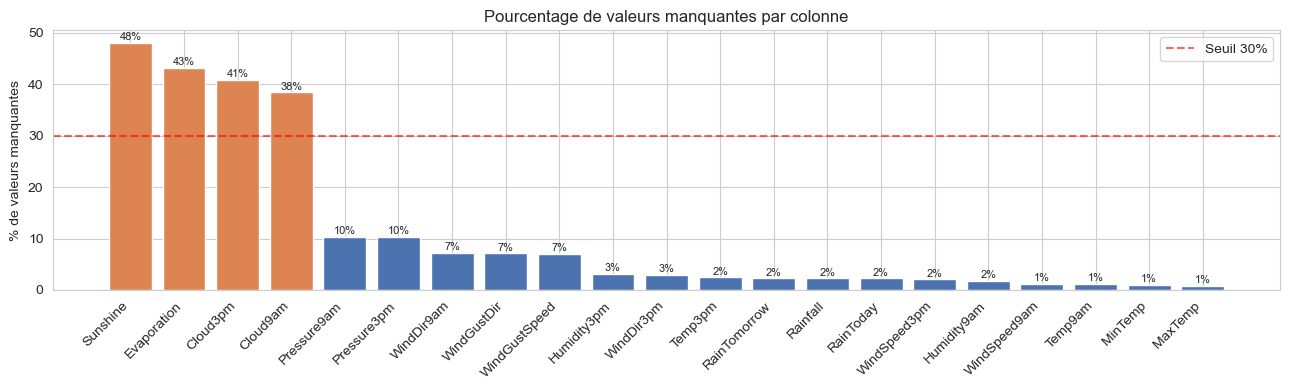

Sunshine         48.009762
Evaporation      43.166506
Cloud3pm         40.807095
Cloud9am         38.421559
Pressure9am      10.356799
Pressure3pm      10.331363
WindDir9am        7.263853
WindGustDir       7.098859
WindGustSpeed     7.055548
Humidity3pm       3.098446
WindDir3pm        2.906641
Temp3pm           2.481094
RainTomorrow      2.245978
Rainfall          2.241853
RainToday         2.241853
WindSpeed3pm      2.105046
Humidity9am       1.824557
WindSpeed9am      1.214767
Temp9am           1.214767
MinTemp           1.020899
MaxTemp           0.866905
dtype: float64


In [22]:
na_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
na_pct = na_pct[na_pct > 0]

fig, ax = plt.subplots(figsize=(13, 4))
colors = ['#DD8452' if v > 30 else '#4C72B0' for v in na_pct.values]
ax.bar(na_pct.index, na_pct.values, color=colors)
ax.axhline(30, color='red', linestyle='--', alpha=0.6, label='Seuil 30%')
ax.set_ylabel('% de valeurs manquantes')
ax.set_title('Pourcentage de valeurs manquantes par colonne')
ax.set_xticklabels(na_pct.index, rotation=45, ha='right')
ax.legend()
for i, (col, val) in enumerate(na_pct.items()):
    ax.text(i, val + 0.5, f'{val:.0f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print(na_pct)

**Analyse :**

- `Sunshine` (48%) et `Evaporation` (43%) ont plus de 40% de NaN. Ce sont pourtant des variables tres informatives pour la pluie. On les conserve et on imputera par la mediane.
- Les autres colonnes (moins de 11% de NaN) : imputation simple suffisante.
- Strategie adoptee : on ne supprime aucune colonne a cause des NaN, on impute intelligemment.

### 1.2 - Distribution de la cible : le desequilibre de classes

Imaginez un medecin qui diagnostique une maladie rare touchant 1% de la population. Un modele qui dit "tout le monde est en bonne sante" aurait 99% d'accuracy... mais serait completement inutile. C'est exactement le meme probleme ici.

C'est pourquoi l'accuracy est une mauvaise metrique pour ce probleme. On utilisera le F2-score et le Brier Score a la place.

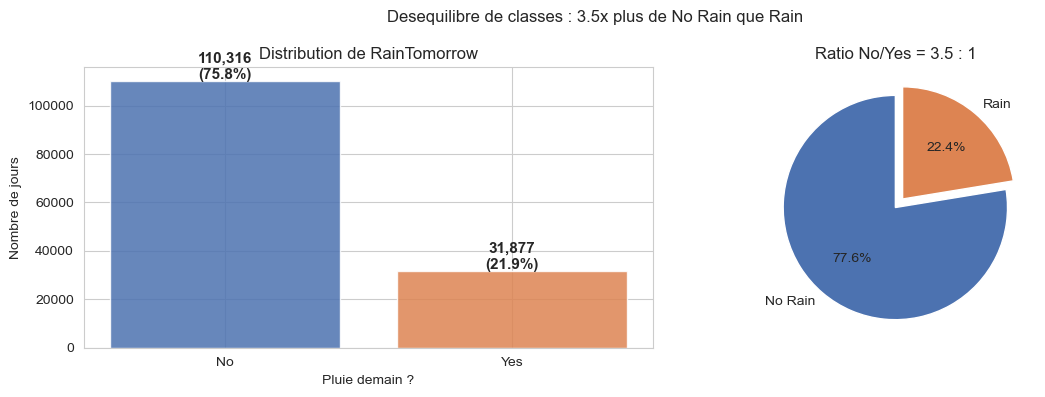

Le modele naif ("il ne pleut jamais") aurait 77.6% d'accuracy.
L'accuracy est donc une mauvaise metrique pour ce probleme.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_raw['RainTomorrow'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'], alpha=0.85)
axes[0].set_title('Distribution de RainTomorrow')
axes[0].set_xlabel('Pluie demain ?')
axes[0].set_ylabel('Nombre de jours')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 600, f'{v:,}\n({v/len(df_raw)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)

axes[1].pie(counts.values, labels=['No Rain', 'Rain'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title(f'Ratio No/Yes = {counts["No"]/counts["Yes"]:.1f} : 1')

plt.suptitle('Desequilibre de classes : 3.5x plus de No Rain que Rain', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '01_target_distribution.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f'Le modele naif ("il ne pleut jamais") aurait {counts["No"]/counts.sum()*100:.1f}% d\'accuracy.')
print('L\'accuracy est donc une mauvaise metrique pour ce probleme.')

### 1.3 - Saisonnalite

La meteo n'est pas aleatoire dans le temps. En Australie, l'hiver austral (juin-aout) correspond a la saison des pluies dans le sud. Si on ignore ce pattern temporel, le modele sera incapable de le capturer.

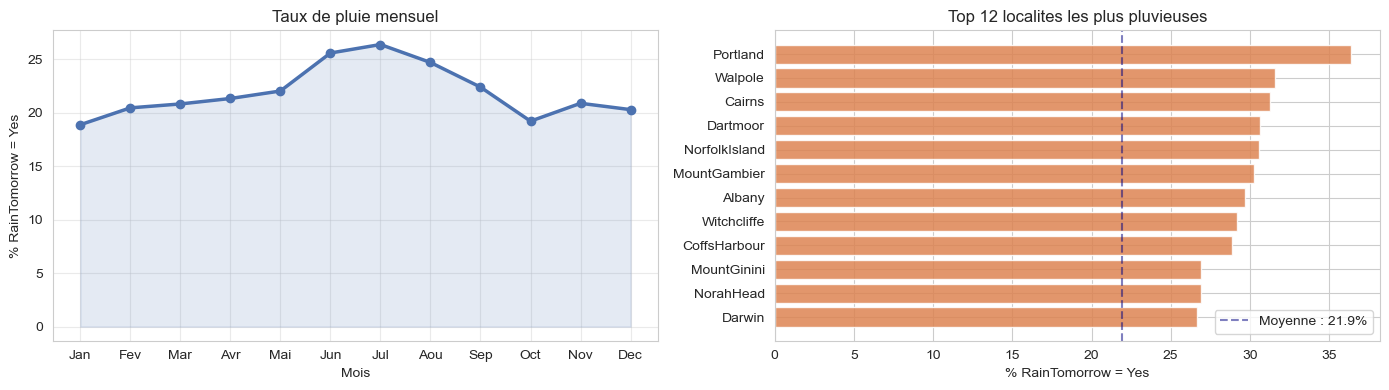

In [24]:
df_eda = df_raw.copy()
df_eda['Date']  = pd.to_datetime(df_eda['Date'])
df_eda['Month'] = df_eda['Date'].dt.month
df_eda['Year']  = df_eda['Date'].dt.year
df_eda['RainTomorrow_num'] = (df_eda['RainTomorrow'] == 'Yes').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly = df_eda.groupby('Month')['RainTomorrow_num'].mean() * 100
axes[0].plot(monthly.index, monthly.values, marker='o', color='#4C72B0', linewidth=2.5)
axes[0].fill_between(monthly.index, monthly.values, alpha=0.15, color='#4C72B0')
axes[0].set_title('Taux de pluie mensuel')
axes[0].set_xlabel('Mois')
axes[0].set_ylabel('% RainTomorrow = Yes')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec'])
axes[0].grid(alpha=0.4)

location_rain = df_eda.groupby('Location')['RainTomorrow_num'].mean().sort_values(ascending=False).head(12) * 100
axes[1].barh(location_rain.index[::-1], location_rain.values[::-1], color='#DD8452', alpha=0.85)
axes[1].set_title('Top 12 localites les plus pluvieuses')
axes[1].set_xlabel('% RainTomorrow = Yes')
axes[1].axvline(monthly.mean(), color='navy', linestyle='--', alpha=0.5,
                label=f'Moyenne : {monthly.mean():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '03_seasonality.png'), dpi=100, bbox_inches='tight')
plt.show()

### 1.4 - Correlations avec la cible

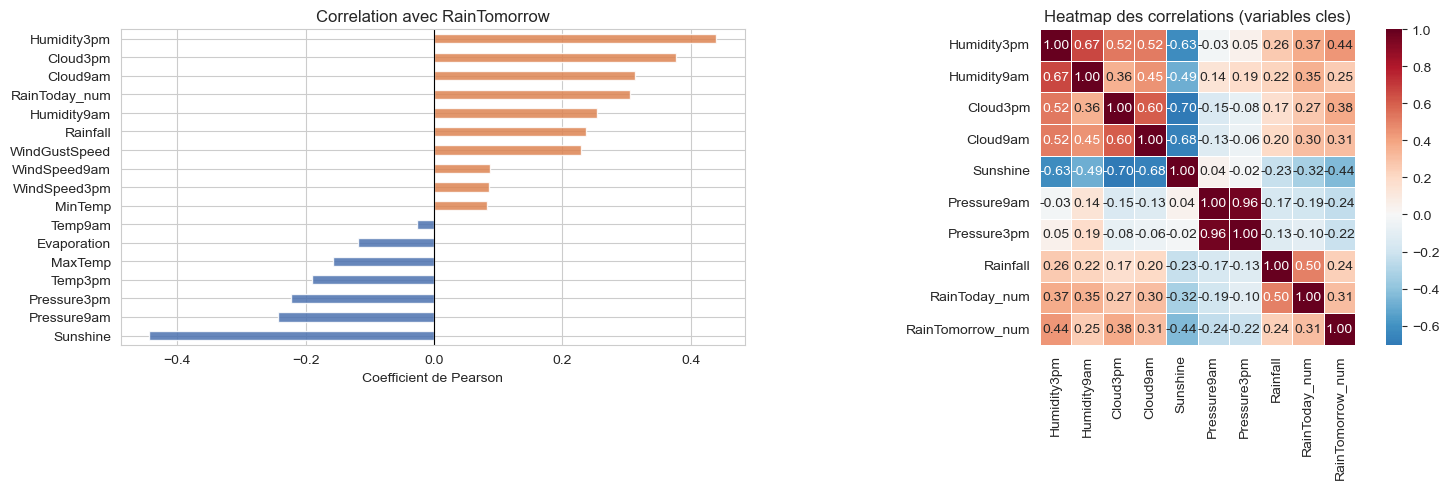

Variables les plus liees positivement a la pluie demain :
RainToday_num    0.305744
Cloud9am         0.313025
Cloud3pm         0.377607
Humidity3pm      0.439929

Variables les plus liees negativement a la pluie demain :
Sunshine      -0.443561
Pressure9am   -0.243348
Pressure3pm   -0.223351
Temp3pm       -0.190073


In [25]:
df_corr = df_eda.copy()
df_corr['RainToday_num'] = (df_corr['RainToday'] == 'Yes').astype(int)

num_cols = df_corr.select_dtypes(include='float64').columns.tolist() + ['RainToday_num', 'RainTomorrow_num']
num_cols = list(dict.fromkeys(num_cols))

corr_matrix = df_corr[num_cols].corr()
corr_target = corr_matrix['RainTomorrow_num'].drop('RainTomorrow_num')
corr_target = pd.Series(corr_target.values, index=corr_target.index).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr_target.values]
corr_target.plot(kind='barh', ax=axes[0], color=colors, alpha=0.85)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Correlation avec RainTomorrow')
axes[0].set_xlabel('Coefficient de Pearson')

key_cols = ['Humidity3pm','Humidity9am','Cloud3pm','Cloud9am','Sunshine',
            'Pressure9am','Pressure3pm','Rainfall','RainToday_num','RainTomorrow_num']
key_cols = [c for c in key_cols if c in df_corr.columns]
sns.heatmap(df_corr[key_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1], square=True, linewidths=0.5)
axes[1].set_title('Heatmap des correlations (variables cles)')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '02_correlation_target.png'), dpi=100, bbox_inches='tight')
plt.show()

print('Variables les plus liees positivement a la pluie demain :')
print(corr_target.tail(4).to_string())
print('\nVariables les plus liees negativement a la pluie demain :')
print(corr_target.head(4).to_string())

### 1.5 - Distributions par classe

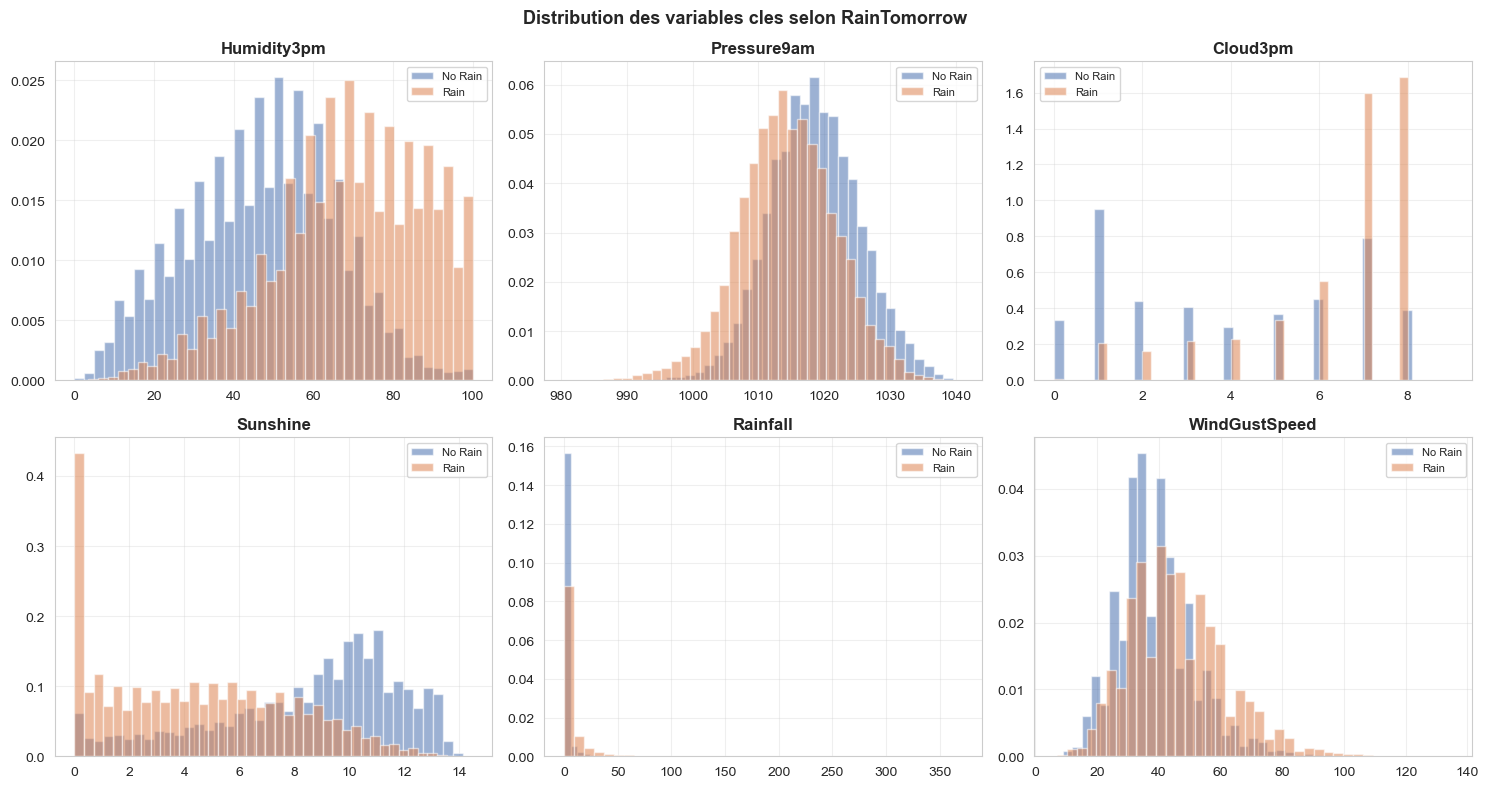

Observations :
- Humidity3pm > 70% : tres souvent associe a la pluie
- Pressure9am < 1010 hPa : zone de basse pression = front pluvieux
- Sunshine < 4h : journee couverte = risque de pluie
- Cloud3pm > 6 : ciel tres couvert = pluie imminente
- Rainfall > 1mm : signal direct, mais les traces infimes (< 0.5mm) sont ambigues (bruit de capteur)
- WindGustSpeed : mediane plus elevee les jours de pluie (~50 km/h vs ~38 km/h en jour sec).
  La distribution presente une longue queue droite : les valeurs > 100 km/h correspondent
  a des tempetes et cyclones, evenements rares mais physiquement reels. On ne les supprime pas.


In [26]:
key_num = ['Humidity3pm', 'Pressure9am', 'Cloud3pm', 'Sunshine', 'Rainfall', 'WindGustSpeed']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), key_num):
    if col not in df_eda.columns:
        continue
    for label, color, name in [(0,'#4C72B0','No Rain'), (1,'#DD8452','Rain')]:
        data = df_eda[df_eda['RainTomorrow_num'] == label][col].dropna()
        ax.hist(data, bins=40, alpha=0.55, color=color, label=name, density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Distribution des variables cles selon RainTomorrow', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observations :')
print('- Humidity3pm > 70% : tres souvent associe a la pluie')
print('- Pressure9am < 1010 hPa : zone de basse pression = front pluvieux')
print('- Sunshine < 4h : journee couverte = risque de pluie')
print('- Cloud3pm > 6 : ciel tres couvert = pluie imminente')
print('- Rainfall > 1mm : signal direct, mais les traces infimes (< 0.5mm) sont ambigues (bruit de capteur)')
print('- WindGustSpeed : mediane plus elevee les jours de pluie (~50 km/h vs ~38 km/h en jour sec).')
print('  La distribution presente une longue queue droite : les valeurs > 100 km/h correspondent')
print('  a des tempetes et cyclones, evenements rares mais physiquement reels. On ne les supprime pas.')

### Visualisation des outliers

Les boites a moustaches (boxplots) sont l outil standard pour visualiser la dispersion et les valeurs extremes.
La boite centrale couvre l intervalle interquartile (Q25-Q75). Les points au-dela des moustaches sont les outliers statistiques.

Rappel : un outlier statistique n est pas forcement une erreur de mesure.
WindGustSpeed a 130 km/h est un cyclone, pas un capteur defaillant.
On distingue deux cas :

- Aberration physique (humidite > 100%) : impossible, erreur de capteur, a supprimer
- Outlier statistique extreme mais possible (vent fort, pluie exceptionnelle) : a conserver, le RobustScaler s en occupera

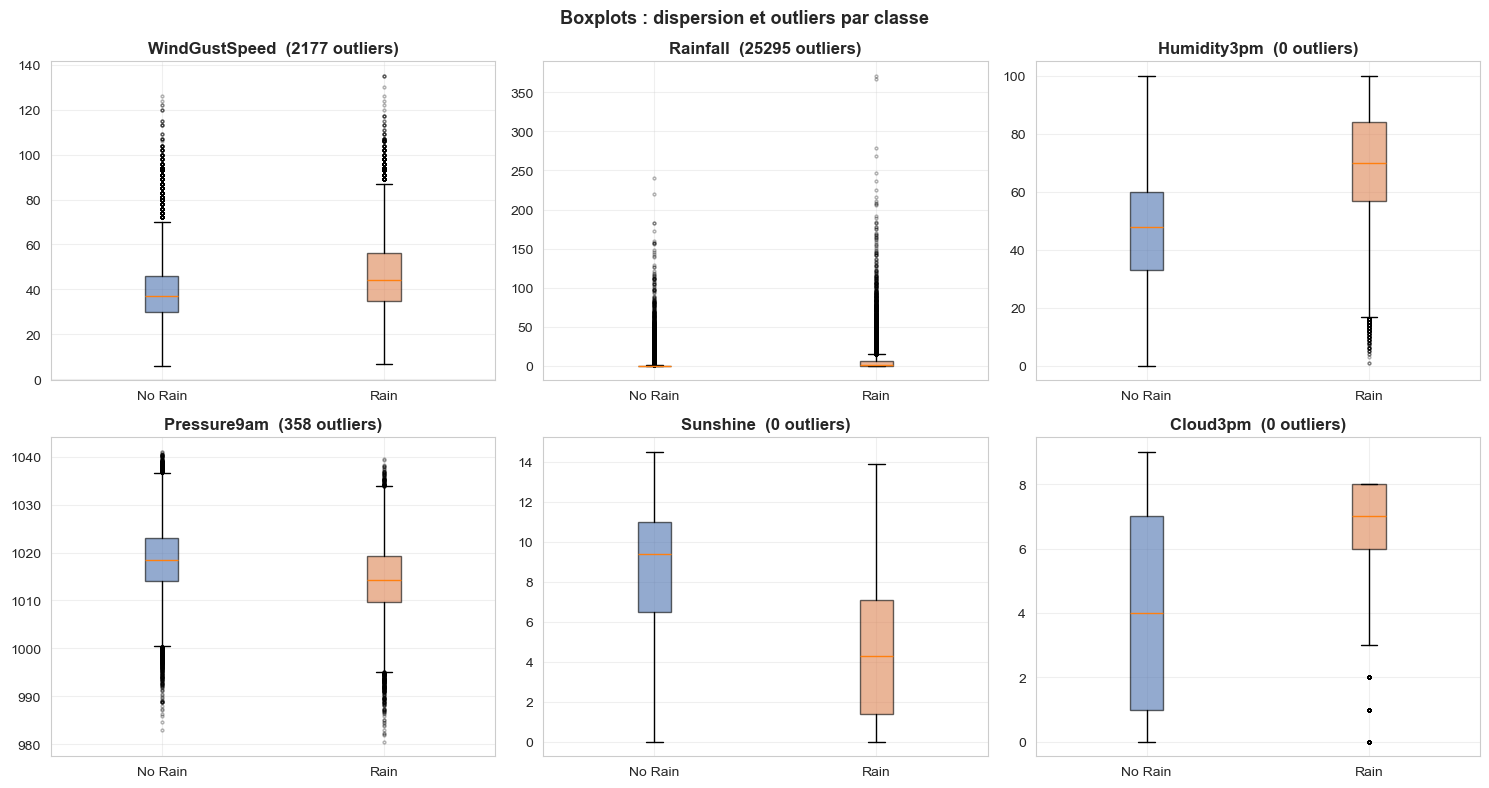

WindGustSpeed : max=135 km/h | Q25=31 | mediane=39 | Q75=48 | IQR=17
Outliers statistiques (> Q75 + 1.5 x IQR) : 3092 observations (2.3%)
Ces valeurs extremes correspondent a des tempetes et cyclones : on les conserve.


In [27]:
vars_outliers = ['WindGustSpeed', 'Rainfall', 'Humidity3pm', 'Pressure9am', 'Sunshine', 'Cloud3pm']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), vars_outliers):
    if col not in df_eda.columns:
        continue
    data_no  = df_eda[df_eda['RainTomorrow_num'] == 0][col].dropna()
    data_yes = df_eda[df_eda['RainTomorrow_num'] == 1][col].dropna()

    bp = ax.boxplot([data_no, data_yes],
                    labels=['No Rain', 'Rain'],
                    patch_artist=True,
                    flierprops=dict(marker='o', markersize=2, alpha=0.3, linestyle='none'))

    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][1].set_facecolor('#DD8452')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_alpha(0.6)

    q75 = data_no.quantile(0.75)
    q25 = data_no.quantile(0.25)
    n_out = int((data_no > q75 + 1.5 * (q75 - q25)).sum() + (data_yes > data_yes.quantile(0.75) + 1.5 * (data_yes.quantile(0.75) - data_yes.quantile(0.25))).sum())
    ax.set_title(f'{col}  ({n_out} outliers)', fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Boxplots : dispersion et outliers par classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Details WindGustSpeed
wgs = df_eda['WindGustSpeed'].dropna()
q75, q25 = wgs.quantile(0.75), wgs.quantile(0.25)
iqr = q75 - q25
n_outliers = int((wgs > q75 + 1.5 * iqr).sum())
print(f'WindGustSpeed : max={wgs.max():.0f} km/h | Q25={q25:.0f} | mediane={wgs.median():.0f} | Q75={q75:.0f} | IQR={iqr:.0f}')
print(f'Outliers statistiques (> Q75 + 1.5 x IQR) : {n_outliers} observations ({100*n_outliers/len(wgs):.1f}%)')
print('Ces valeurs extremes correspondent a des tempetes et cyclones : on les conserve.')

---
## Etape 2 - Cleaning

### Objectif

Nettoyer les donnees sans en supprimer trop. Chaque ligne supprimee est une information perdue.

### Concept : que supprimer ?

Il y a deux types de "mauvaises" donnees :

**Les aberrations physiques** : valeurs impossibles dans la realite (humidite a 120%, pression a -50 hPa). Ce sont des erreurs de capteur a supprimer.

**Les outliers statistiques** : valeurs extremes mais physiquement possibles (vent a 130 km/h = cyclone rare mais reel). On les garde. Le RobustScaler les gerera.

Exemple : si un releve dit qu'il faisait 200 degres a Melbourne, c'est une erreur de thermometre. Mais si ca dit 48 degres, c'est chaud mais possible (record Australie : 50.7 degres).

In [28]:
df = pd.read_csv(DATA_PATH)
n_initial = len(df)

# Doublons
n_dup = df.duplicated().sum()
df = df.drop_duplicates()

# Date -> datetime
df['Date'] = pd.to_datetime(df['Date'])

# Aberrations physiques uniquement
aberrations = {
    'Humidity9am <= 100%':    lambda d: (d['Humidity9am'].isna()) | (d['Humidity9am'] <= 100),
    'Humidity3pm <= 100%':    lambda d: (d['Humidity3pm'].isna()) | (d['Humidity3pm'] <= 100),
    'Rainfall >= 0 mm':       lambda d: (d['Rainfall'].isna())    | (d['Rainfall'] >= 0),
    'Pressure9am > 900 hPa':  lambda d: (d['Pressure9am'].isna()) | (d['Pressure9am'] > 900),
    'Pressure3pm > 900 hPa':  lambda d: (d['Pressure3pm'].isna()) | (d['Pressure3pm'] > 900),
    'WindSpeed9am >= 0':      lambda d: (d['WindSpeed9am'].isna())| (d['WindSpeed9am'] >= 0),
    'WindSpeed3pm >= 0':      lambda d: (d['WindSpeed3pm'].isna())| (d['WindSpeed3pm'] >= 0),
}
for rule_name, rule_fn in aberrations.items():
    n_before = len(df)
    df = df[rule_fn(df)]
    removed = n_before - len(df)
    if removed > 0:
        print(f'  Regle [{rule_name}] : {removed} lignes supprimees')

# Lignes sans target (irrécuperables)
n_before = len(df)
df = df.dropna(subset=['RainTomorrow'])
print(f'  Lignes sans target : {n_before - len(df)} supprimees')

# Encoder la target
df['RainTomorrow'] = (df['RainTomorrow'] == 'Yes').astype(int)
df['RainToday']    = df['RainToday'].map({'Yes': 1, 'No': 0})

print(f'\nDoublons supprimes : {n_dup}')
print(f'Total supprime : {n_initial - len(df)} lignes ({(n_initial-len(df))/n_initial*100:.1f}%)')
print(f'Shape finale : {df.shape}')
print(f'Target : {df["RainTomorrow"].value_counts().to_dict()}')

  Lignes sans target : 3267 supprimees

Doublons supprimes : 0
Total supprime : 3267 lignes (2.2%)
Shape finale : (142193, 23)
Target : {0: 110316, 1: 31877}


---
## Etape 3 - Feature Engineering

### Objectif

Creer de nouvelles variables a partir des variables existantes pour donner plus d'information au modele.

### Pourquoi creer des features ?

Les modeles ML ne comprennent pas la physique. Ils ne savent pas que :
- Une chute de pression est signe de pluie imminente
- Une humidite croissante toute la journee indique une saturation atmospherique
- Le mois de juillet en Australie correspond a l'hiver austral et donc plus de pluie dans le sud

En creant ces variables explicitement, on encode la connaissance meteorologique dans les donnees.

### L'encodage cyclique (sin/cos)

Le mois de janvier (1) et decembre (12) sont proches dans le calendrier mais loin numeriquement. Un modele qui recoit Month=12 et Month=1 ne sait pas qu'ils sont adjacents. La solution est d'encoder le mois en cercle :

    Month_sin = sin(2 * pi * Month / 12)
    Month_cos = cos(2 * pi * Month / 12)

Avec cet encodage, janvier et decembre sont au meme endroit sur le cercle. Le modele comprend leur proximite.

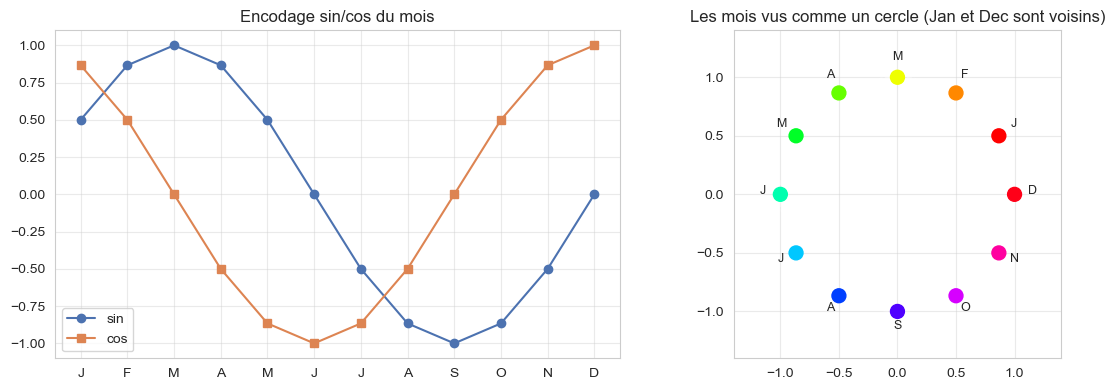

Janvier et decembre sont au meme endroit sur le cercle.
Le modele comprend donc qu'ils sont voisins temporellement.


In [29]:
# Illustration de l'encodage cyclique
months = np.arange(1, 13)
sin_vals = np.sin(2 * np.pi * months / 12)
cos_vals = np.cos(2 * np.pi * months / 12)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(months, sin_vals, 'o-', color='#4C72B0', label='sin')
axes[0].plot(months, cos_vals, 's-', color='#DD8452', label='cos')
axes[0].set_xticks(months)
axes[0].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[0].set_title('Encodage sin/cos du mois')
axes[0].legend()
axes[0].grid(alpha=0.4)

theta = 2 * np.pi * months / 12
axes[1].scatter(np.cos(theta), np.sin(theta), s=100, c=months, cmap='hsv', zorder=3)
for m, t in zip(months, theta):
    axes[1].text(np.cos(t)*1.15, np.sin(t)*1.15,
                 ['J','F','M','A','M','J','J','A','S','O','N','D'][m-1], ha='center', fontsize=9)
circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', alpha=0.5)
axes[1].add_patch(circle)
axes[1].set_xlim(-1.4, 1.4)
axes[1].set_ylim(-1.4, 1.4)
axes[1].set_aspect('equal')
axes[1].set_title('Les mois vus comme un cercle (Jan et Dec sont voisins)')
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()
print('Janvier et decembre sont au meme endroit sur le cercle.')
print('Le modele comprend donc qu\'ils sont voisins temporellement.')

In [30]:
# Trier par Location + Date (obligatoire pour les calculs temporels)
df = df.sort_values(['Location', 'Date']).reset_index(drop=True)

# Variables temporelles
df['Month']     = df['Date'].dt.month
df['DayOfYear'] = df['Date'].dt.dayofyear
df['Season']    = df['Month'].map({
    12:'Summer',1:'Summer',2:'Summer',3:'Autumn',4:'Autumn',5:'Autumn',
    6:'Winter',7:'Winter',8:'Winter',9:'Spring',10:'Spring',11:'Spring'
})
df['Month_sin']     = np.sin(2*np.pi*df['Month']/12)
df['Month_cos']     = np.cos(2*np.pi*df['Month']/12)
df['DayOfYear_sin'] = np.sin(2*np.pi*df['DayOfYear']/365)
df['DayOfYear_cos'] = np.cos(2*np.pi*df['DayOfYear']/365)

# Derivees temporelles 9h -> 15h (evolution dans la journee)
# Un delta negatif de pression signifie que la pression baisse = front meteorologique approchant
df['Delta_Pressure'] = df['Pressure3pm'] - df['Pressure9am']
df['Delta_Humidity'] = df['Humidity3pm'] - df['Humidity9am']
df['Delta_Temp']     = df['Temp3pm']     - df['Temp9am']
df['Delta_Wind']     = df['WindSpeed3pm']- df['WindSpeed9am']

# Variation par rapport au jour precedent (J-1)
for col in ['Pressure9am', 'Humidity3pm', 'MaxTemp']:
    lag = df.groupby('Location')[col].shift(1)
    df[f'{col}_diff1'] = df[col] - lag

# Fenetres glissantes 3 jours - on utilise shift(1) pour ne regarder que le passe
# Important : sans shift(1), on incorporerait la valeur du jour J dans la moyenne
# ce qui creeraitune fuite de donnees
for col in ['Rainfall', 'Humidity3pm', 'Pressure9am']:
    df[f'{col}_roll3_mean'] = df.groupby('Location')[col].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
    df[f'{col}_roll3_max'] = df.groupby('Location')[col].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).max()
    )

# Flags binaires : signaux meteorologiques discrets
df['Pressure_drop_flag']  = (df['Delta_Pressure'] < -2).astype(int)
df['HighHumidity_flag']   = (df['Humidity3pm'] > 85).astype(int)
df['StrongWind_flag']     = (df['WindGustSpeed'] > 60).astype(int)
df['HumidityRising_flag'] = (df['Delta_Humidity'] > 10).astype(int)
df['PressureLow_flag']    = (df['Pressure9am'] < 1010).astype(int)

# Interactions
df['Rain_x_Humidity'] = df['RainToday'].fillna(0) * df['Humidity3pm'].fillna(df['Humidity3pm'].median())
df['Wind_x_Humidity'] = df['WindGustSpeed'].fillna(0) * df['Humidity3pm'].fillna(df['Humidity3pm'].median())
df['TempRange']       = df['MaxTemp'] - df['MinTemp']

# Encodage cyclique des directions de vent
# Probleme identique au mois : le Nord (0 degres) et le NNW (337.5 degres) sont voisins
wind_dir_map = {
    'N':0,'NNE':22.5,'NE':45,'ENE':67.5,'E':90,'ESE':112.5,'SE':135,'SSE':157.5,
    'S':180,'SSW':202.5,'SW':225,'WSW':247.5,'W':270,'WNW':292.5,'NW':315,'NNW':337.5
}
for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:
    angles = df[col].map(wind_dir_map)
    df[f'{col}_sin'] = np.sin(np.radians(angles))
    df[f'{col}_cos'] = np.cos(np.radians(angles))

df = df.drop(columns=['WindGustDir', 'WindDir9am', 'WindDir3pm'])

new_features = [c for c in df.columns if any(x in c for x in
    ['Delta','flag','roll3','sin','cos','diff1','Range','x_'])]
print(f'{len(new_features)} nouvelles features creees :')
for f in sorted(new_features):
    print(f'  - {f}')
print(f'\nShape totale : {df.shape}')

31 nouvelles features creees :
  - DayOfYear_cos
  - DayOfYear_sin
  - Delta_Humidity
  - Delta_Pressure
  - Delta_Temp
  - Delta_Wind
  - HighHumidity_flag
  - Humidity3pm_diff1
  - Humidity3pm_roll3_max
  - Humidity3pm_roll3_mean
  - HumidityRising_flag
  - MaxTemp_diff1
  - Month_cos
  - Month_sin
  - Pressure9am_diff1
  - Pressure9am_roll3_max
  - Pressure9am_roll3_mean
  - PressureLow_flag
  - Pressure_drop_flag
  - Rain_x_Humidity
  - Rainfall_roll3_max
  - Rainfall_roll3_mean
  - StrongWind_flag
  - TempRange
  - WindDir3pm_cos
  - WindDir3pm_sin
  - WindDir9am_cos
  - WindDir9am_sin
  - WindGustDir_cos
  - WindGustDir_sin
  - Wind_x_Humidity

Shape totale : (142193, 54)


---
## Etape 4 - Split Train / Test CHRONOLOGIQUE

### Objectif

Separer les donnees en deux groupes sans regarder le futur depuis le passe.

### Pourquoi un split chronologique et pas aleatoire ?

C'est l'une des decisions les plus importantes du projet. Voici pourquoi.

Un split aleatoire (train_test_split avec random_state) sur des donnees temporelles est une erreur fondamentale. Le modele peut s'entrainer sur des donnees de 2016 et etre evalue sur des donnees de 2009. Il a donc "vu le futur" pendant l'entrainement. Les metriques sont alors artificiellement gonflees - elles ne refletent pas la vraie capacite du modele a predire des jours qu'il n'a jamais vus.

Illustration :

    Split aleatoire (incorrect pour donnees temporelles)
    2007  2010  2013  2008  2015  2011  2016  2009
     [T]   [Ts]  [T]  [Ts]   [T]  [Ts]   [T]  [Ts]
    (T=train, Ts=test, melanges aleatoirement)

    Split chronologique (correct)
    2007  2008  2009  2010  2011  2012  2013  2014 | 2015  2016  2017
    <------------- TRAIN (80%) -------------------> <-- TEST (20%) -->

Les metriques avec split chronologique sont generalement plus basses qu'avec split aleatoire. Mais elles sont honnetes, ce qui est ce qui compte.

Date de coupure : 2015-08-08
Train : 2007-11-01 -> 2015-08-08 (109,302 obs.)
Test  : 2015-08-08 -> 2017-06-25 (32,891 obs.)

Train : (109302, 52) | ratio pluie : 0.226 (22.6%)
Test  : (32891, 52)  | ratio pluie : 0.219 (21.9%)

A partir d'ici, X_test ne sera utilise qu'a l'etape 12 pour l'evaluation finale.


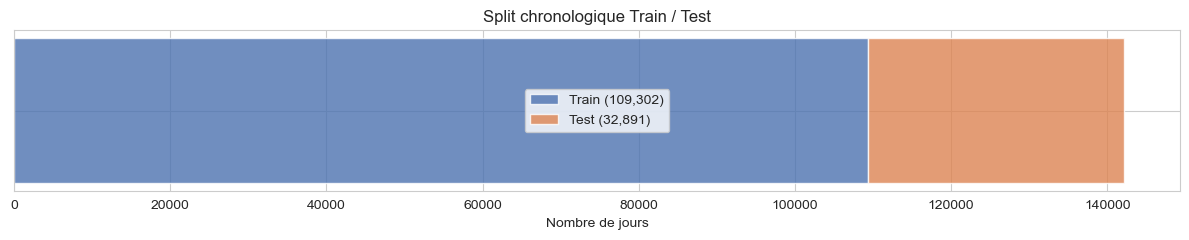

In [31]:
# Coupure sur les 80% de dates uniques
unique_dates = df['Date'].sort_values().unique()
cutoff_date  = unique_dates[int(len(unique_dates) * 0.8)]

train_mask = df['Date'] <  cutoff_date
test_mask  = df['Date'] >= cutoff_date

print(f'Date de coupure : {pd.Timestamp(cutoff_date).date()}')
print(f'Train : {df["Date"].min().date()} -> {pd.Timestamp(cutoff_date).date()} ({train_mask.sum():,} obs.)')
print(f'Test  : {pd.Timestamp(cutoff_date).date()} -> {df["Date"].max().date()} ({test_mask.sum():,} obs.)')

# Dropper la Date de X (les features cycliques la representent deja)
df = df.drop(columns=['Date'])

X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

X_train = X[train_mask].reset_index(drop=True)
X_test  = X[test_mask].reset_index(drop=True)
y_train = y[train_mask].reset_index(drop=True)
y_test  = y[test_mask].reset_index(drop=True)

print(f'\nTrain : {X_train.shape} | ratio pluie : {y_train.mean():.3f} ({y_train.mean()*100:.1f}%)')
print(f'Test  : {X_test.shape}  | ratio pluie : {y_test.mean():.3f} ({y_test.mean()*100:.1f}%)')
print(f'\nA partir d\'ici, X_test ne sera utilise qu\'a l\'etape 12 pour l\'evaluation finale.')

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.barh([''], [train_mask.sum()], color='#4C72B0', alpha=0.8, label=f'Train ({train_mask.sum():,})')
ax.barh([''], [test_mask.sum()], left=[train_mask.sum()], color='#DD8452', alpha=0.8,
        label=f'Test ({test_mask.sum():,})')
ax.set_title('Split chronologique Train / Test')
ax.legend(loc='center')
ax.set_xlabel('Nombre de jours')
plt.tight_layout()
plt.show()

---
## Etape 5 - Preprocessing (Pipeline sklearn)

### Objectif

Preparer les donnees numeriquement pour que les algorithmes puissent les traiter correctement.

### Pourquoi normaliser ?

La temperature varie entre -8 et +48 degres Celsius. La pression entre 980 et 1041 hPa. Si on ne normalise pas, la pression ecrase numeriquement la temperature dans les calculs mathematiques, non pas parce qu'elle est plus importante, mais simplement parce qu'elle a des valeurs plus grandes.

### Pourquoi RobustScaler plutot que StandardScaler ?

    StandardScaler : (x - moyenne) / ecart-type
    Probleme : la moyenne et l'ecart-type sont tres sensibles aux valeurs extremes.

    RobustScaler  : (x - mediane) / (Q75 - Q25)
    Avantage : utilise la mediane et l'IQR, qui sont resistants aux outliers.

En meteorologie, les cyclones, canicules et tempetes creent des valeurs extremes reelles. RobustScaler est donc plus adapte.

### Pourquoi un Pipeline ?

Le Pipeline sklearn garantit que toute transformation (normalisation, imputation) est apprise sur le train uniquement, puis appliquee au test. Sans pipeline, on risque d'apprendre la normalisation sur l'ensemble du dataset, ce qui constitue une fuite de donnees (data leakage).

In [32]:
numeric_features     = X_train.select_dtypes(include=['float64','int64','int32']).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print(f'Variables numeriques ({len(numeric_features)}) : {numeric_features}')
print(f'\nVariables categorielles ({len(categorical_features)}) : {categorical_features}')

preprocessor = ColumnTransformer(transformers=[
    # Pipeline variables numeriques :
    # 1) Imputer par la mediane (robuste aux outliers) pour les NaN
    # 2) RobustScaler pour normaliser
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ]), numeric_features),

    # Pipeline variables categorielles :
    # 1) Imputer par le mode pour les NaN
    # 2) OneHotEncoder : cree une colonne binaire par categorie
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
], remainder='drop')

print('\nPreprocessor defini. Le pipeline garantit l\'absence de data leakage.')

Variables numeriques (50) : ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'Month', 'DayOfYear', 'Month_sin', 'Month_cos', 'DayOfYear_sin', 'DayOfYear_cos', 'Delta_Pressure', 'Delta_Humidity', 'Delta_Temp', 'Delta_Wind', 'Pressure9am_diff1', 'Humidity3pm_diff1', 'MaxTemp_diff1', 'Rainfall_roll3_mean', 'Rainfall_roll3_max', 'Humidity3pm_roll3_mean', 'Humidity3pm_roll3_max', 'Pressure9am_roll3_mean', 'Pressure9am_roll3_max', 'Pressure_drop_flag', 'HighHumidity_flag', 'StrongWind_flag', 'HumidityRising_flag', 'PressureLow_flag', 'Rain_x_Humidity', 'Wind_x_Humidity', 'TempRange', 'WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos']

Variables categorielles (2) : ['Location', 'Season']

Preprocessor defini. Le pipeline garantit l'absence de data leakage.


## Etape 6 - Ponderation anti-label-noise (envisagee, non retenue)

### L'idee

Les donnees meteo contiennent du bruit d'etiquetage. Deux cas typiques :

**Cas 1 :** 0.2mm de pluie hier, RainToday = 'Yes' (compte-goutte sur le pluviometre). Est-ce vraiment de la pluie au sens meteorologique ? Le jour est ambigu.

**Cas 2 :** 5mm de pluie et RainTomorrow = 'Yes' : cas clairement positif.

L'idee etait de ponderer chaque observation pour reduire l'influence des cas ambigus et renforcer les cas francs :

| Cas | Poids | Raison |
|-----|-------|--------|
| Rainfall < 0.5mm et Rain=1 | 0.6 | Pluie trop faible pour etre fiable |
| Humidity entre 60 et 75% et Rain=0 | 0.8 | Zone ambigue de l'humidite |
| Rainfall > 5mm et Rain=1 | 1.5 | Cas clairement positif |
| Autres | 1.0 | Neutre |

### Pourquoi on ne la retient pas

1. **Double comptage.** Le desequilibre de classe est deja gere par `class_weight='balanced'` (RandomForest, LightGBM) et `scale_pos_weight` (XGBoost). Ajouter un `sample_weight` multiplierait les deux ponderations et fausserait l'equilibrage voulu.

2. **Seuils non valides.** Les bornes (0.5mm, 60-75%, 5mm) et les poids (0.6 / 0.8 / 1.5) sont arbitraires et n'ont jamais ete valides en cross-validation.

3. **Contraire a l'objectif F2.** Sous-ponderer des jours de pluie (Rainfall < 0.5mm et Rain=1) reduit le rappel sur la classe pluie, alors que le F2 privilegie le rappel.

Le rebalancement repose donc uniquement sur `class_weight` / `scale_pos_weight`, methode standard et suffisante ici.

---
## Etape 7 - Feature Selection automatique

### Objectif

Garder uniquement les variables les plus informatives et reduire le bruit.

### Mutual Information vs Correlation de Pearson

La correlation de Pearson ne mesure que les relations lineaires. Si l'humidite a 90% provoque la pluie de maniere non-lineaire (effet seuil), la correlation ne le verra pas.

L'Information Mutuelle (Mutual Information) mesure la dependance generale entre deux variables, quelle que soit sa forme. C'est la quantite d'information qu'une variable donne sur une autre.

Pour faire simple : la correlation de Pearson demande "sont-ils proportionnels ?". L'Information Mutuelle demande "est-ce qu'en connaissant X, j'en sais plus sur Y ?"

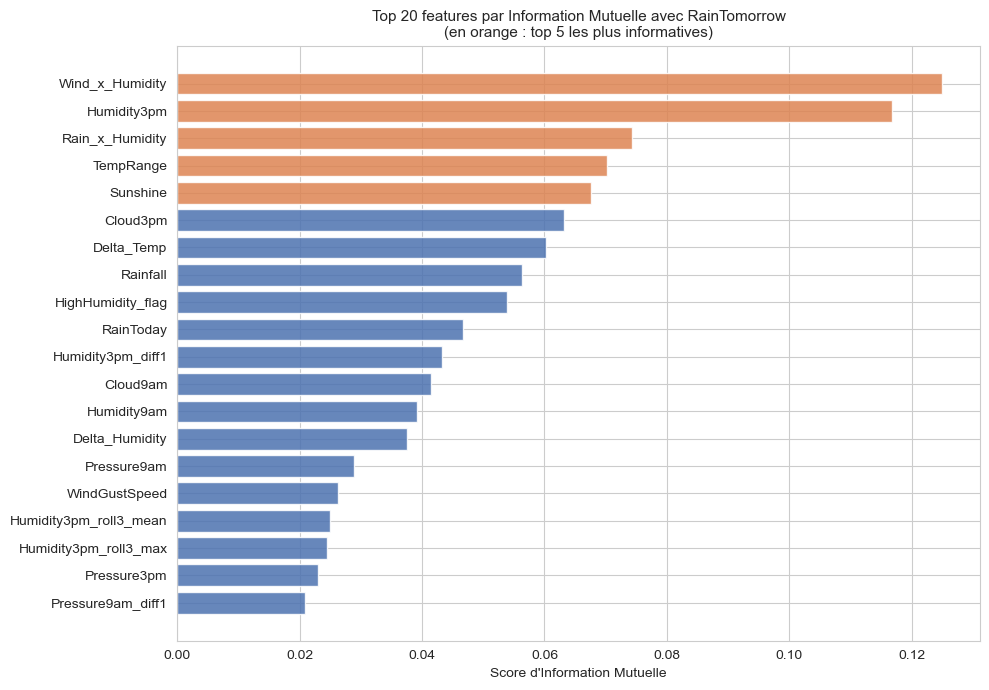

Top 10 features les plus informatives :
  Wind_x_Humidity                MI = 0.1249
  Humidity3pm                    MI = 0.1168
  Rain_x_Humidity                MI = 0.0743
  TempRange                      MI = 0.0703
  Sunshine                       MI = 0.0676
  Cloud3pm                       MI = 0.0632
  Delta_Temp                     MI = 0.0603
  Rainfall                       MI = 0.0563
  HighHumidity_flag              MI = 0.0539
  RainToday                      MI = 0.0467


In [33]:
# Calcul des scores de Mutual Information pour visualisation
prep_temp = ColumnTransformer(transformers=[
    ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), numeric_features),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
     categorical_features)
])

X_prep_temp = prep_temp.fit_transform(X_train)
ohe_cols    = prep_temp.named_transformers_['cat']['ohe'].get_feature_names_out(categorical_features)
all_feat    = np.array(numeric_features + list(ohe_cols))

mi_scores = mutual_info_classif(X_prep_temp, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': all_feat, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top20 = mi_df.head(20)
colors_mi = ['#DD8452' if i < 5 else '#4C72B0' for i in range(20)]
ax.barh(top20['feature'][::-1], top20['mi_score'][::-1], color=colors_mi[::-1], alpha=0.85)
ax.set_title('Top 20 features par Information Mutuelle avec RainTomorrow\n(en orange : top 5 les plus informatives)', fontsize=11)
ax.set_xlabel('Score d\'Information Mutuelle')
plt.tight_layout()
plt.show()

print('Top 10 features les plus informatives :')
for _, row in mi_df.head(10).iterrows():
    print(f'  {row["feature"]:<30} MI = {row["mi_score"]:.4f}')

---
## Etape 8 - Pas de SMOTE

### Pourquoi ne pas utiliser SMOTE en meteorologie ?

SMOTE (Synthetic Minority Over-sampling Technique) cree des observations synthetiques en interpolant entre des observations existantes de la classe minoritaire.

En meteorologie, cela pose deux problemes fondamentaux :

**Probleme 1 - Non physique :** SMOTE cree une observation "entre" deux jours de pluie reels. Cette observation n'existe pas dans la realite. Ce n'est pas un etat physique de l'atmosphere.

    Observation reelle A : Pression=1005, Humidite=85%, Vent=45 km/h -> Pluie
    Observation reelle B : Pression=1012, Humidite=72%, Vent=20 km/h -> Pluie
    SMOTE genere :         Pression=1008, Humidite=78%, Vent=32 km/h -> Pluie ???

**Probleme 2 - Structure temporelle :** Les donnees meteo sont correlees dans le temps. SMOTE cree un faux "jour" qui brise cette structure temporelle.

**Notre alternative :** class_weight='balanced' dans les modeles, et scale_pos_weight pour XGBoost, combines avec nos sample_weights definis en etape 6.

Regle generale : pour des donnees temporelles ou des donnees physiques (meteo, hydrologie, finance), SMOTE est deconseille.

---
## Etape 9 - Training : Comparaison de modeles

### Objectif

Evaluer plusieurs modeles en cross-validation pour identifier le plus prometteur.

### La Cross-Validation Stratifiee (5-fold)

Au lieu d'entrainer une seule fois et tester une seule fois (ce qui peut etre du au hasard du split), la CV k-fold :

1. Divise le train en 5 groupes (folds)
2. Entraine sur 4 folds, teste sur le 5eme
3. Repete 5 fois en changeant le fold de test
4. Retourne la moyenne et l'ecart-type des 5 scores

"Stratifiee" : chaque fold conserve le meme ratio No Rain / Rain que le dataset complet, ce qui est essentiel avec des classes desequilibrees.

### Pourquoi F2-score plutot que F1-score ?

Le F1-score donne le meme poids a la precision et au recall :

    F1 = 2 * (Precision * Recall) / (Precision + Recall)

Mais les erreurs ne coutent pas pareil en meteorologie :

- **Faux Negatif** (on predit "pas de pluie", il pleut) : l'agriculteur ne protege pas sa recolte, les travaux en exterieur ne sont pas planifies en consequence. Cout eleve.
- **Faux Positif** (on predit "pluie", il fait beau) : on prend un parapluie inutilement. Cout faible.

Le F2-score penalise davantage les Faux Negatifs. Le recall compte deux fois plus que la precision :

    F2 = 5 * (Precision * Recall) / (4 * Precision + Recall)

Regle generale : utilisez F-beta avec beta > 1 quand manquer un positif est plus grave que declencher une fausse alarme.

In [34]:
# Illustration : F1 vs F2 avec differents profils de modeles
cases = [
    ('Modele A (equilibre)',        0.70, 0.70),
    ('Modele B (precision forte)',  0.85, 0.55),
    ('Modele C (recall fort)',      0.55, 0.85),
]
print('Comparaison F1 vs F2 sur 3 profils de modeles :')
print(f'{"Modele":<30} {"Precision":>10} {"Recall":>8} {"F1":>8} {"F2":>8}')
print('-' * 65)
for name, p, r in cases:
    f1 = 2*p*r/(p+r)
    f2 = 5*p*r/(4*p+r)
    note = '  <- F2 prefere ce modele' if name == 'Modele C (recall fort)' else ''
    print(f'{name:<30} {p:>10.0%} {r:>8.0%} {f1:>8.4f} {f2:>8.4f}{note}')

Comparaison F1 vs F2 sur 3 profils de modeles :
Modele                          Precision   Recall       F1       F2
-----------------------------------------------------------------
Modele A (equilibre)                  70%      70%   0.7000   0.7000
Modele B (precision forte)            85%      55%   0.6679   0.5918
Modele C (recall fort)                55%      85%   0.6679   0.7664  <- F2 prefere ce modele


In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'RandomForest': Pipeline([
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(score_func=mutual_info_fixed, k=35)),
        ('model', RandomForestClassifier(
            n_estimators=300, max_depth=15, min_samples_split=5,
            min_samples_leaf=2, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(score_func=mutual_info_fixed, k=35)),
        ('model', xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
            eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
        ))
    ]),
    'LightGBM': Pipeline([
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(score_func=mutual_info_fixed, k=35)),
        ('model', lgb.LGBMClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        ))
    ])
}

cv_results = {}
for name, pipeline in models.items():
    print(f'CV {name}...', end=' ', flush=True)
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring=f2_scorer, n_jobs=-1)
    cv_results[name] = scores
    print(f'F2 = {scores.mean():.4f} +/- {scores.std():.4f}')

best_cv = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'\nMeilleur modele en CV : {best_cv}')

CV RandomForest... F2 = 0.6673 +/- 0.0043
CV XGBoost... F2 = 0.7288 +/- 0.0029
CV LightGBM... F2 = 0.7285 +/- 0.0036

Meilleur modele en CV : XGBoost


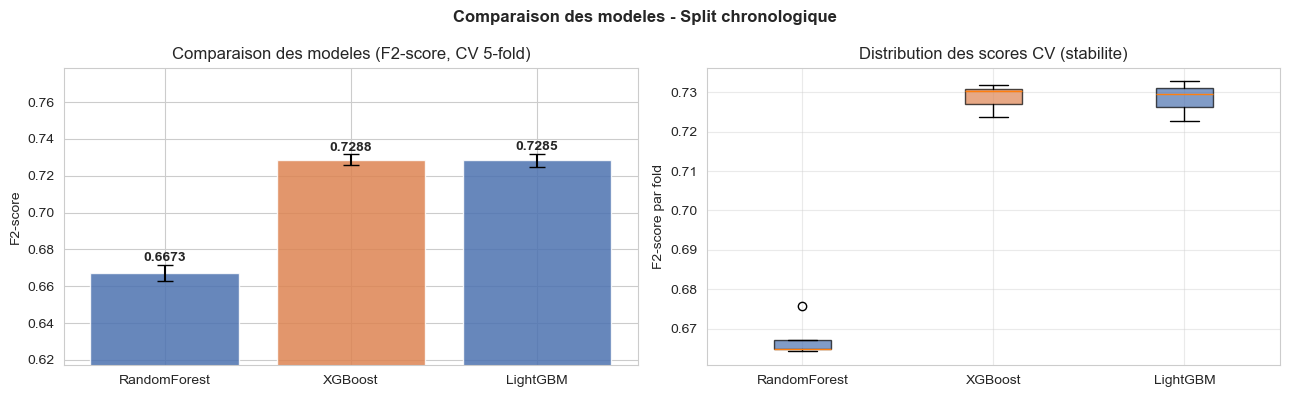

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

names   = list(cv_results.keys())
means   = [cv_results[n].mean() for n in names]
stds    = [cv_results[n].std() for n in names]
cols_bar = ['#DD8452' if m == max(means) else '#4C72B0' for m in means]

bars = axes[0].bar(names, means, yerr=stds, capsize=6, color=cols_bar, alpha=0.85)
axes[0].set_title('Comparaison des modeles (F2-score, CV 5-fold)')
axes[0].set_ylabel('F2-score')
axes[0].set_ylim(min(means) - 0.05, max(means) + 0.05)
for bar, m, s in zip(bars, means, stds):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.002,
                 f'{m:.4f}', ha='center', fontweight='bold', fontsize=10)

data_box = [cv_results[n] for n in names]
bp = axes[1].boxplot(data_box, labels=names, patch_artist=True)
for patch, c in zip(bp['boxes'], cols_bar):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[1].set_title('Distribution des scores CV (stabilite)')
axes[1].set_ylabel('F2-score par fold')
axes[1].grid(alpha=0.4)

plt.suptitle('Comparaison des modeles - Split chronologique', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Etape 10 - Optimisation des Hyperparametres (RandomizedSearchCV)

### Objectif

Trouver les meilleurs reglages pour les deux modeles finalistes.

### GridSearch vs RandomizedSearch

GridSearchCV essaie toutes les combinaisons possibles. Si on a 5 valeurs pour 8 parametres differents, c'est 5^8 = 390 625 combinaisons. C'est inutilement long.

RandomizedSearchCV tire aleatoirement N combinaisons. 30 a 50 iterations suffisent generalement pour trouver une bonne region de l'espace des hyperparametres. C'est le meilleur compromis temps/qualite.

Point important : le nombre de features k de la SelectionKBest est inclus dans l'espace de recherche. On optimise le pipeline complet, pas seulement le modele.

In [37]:
# Tuning LightGBM
lgbm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=mutual_info_fixed, k=35)),
    ('model', lgb.LGBMClassifier(
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ))
])
lgbm_params = {
    'selector__k':              [25, 30, 35, 40],
    'model__n_estimators':      [200, 300, 400, 500],
    'model__max_depth':         [4, 5, 6, 7, 8],
    'model__learning_rate':     [0.03, 0.05, 0.07, 0.1],
    'model__num_leaves':        [31, 50, 63, 80],
    'model__subsample':         [0.7, 0.8, 0.9],
    'model__colsample_bytree':  [0.7, 0.8, 0.9],
    'model__reg_alpha':         [0, 0.1, 0.5],
    'model__reg_lambda':        [0, 0.1, 0.5, 1.0],
    'model__min_child_samples': [10, 20, 30],
}
print('RandomizedSearch LightGBM (30 iterations, scoring=F2)...')
lgbm_search = RandomizedSearchCV(
    lgbm_pipe, lgbm_params, n_iter=30, cv=cv,
    scoring=f2_scorer, n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
lgbm_search.fit(X_train, y_train)
print(f'LightGBM best F2 (CV) : {lgbm_search.best_score_:.4f}')
print('Meilleurs parametres :')
for k, v in lgbm_search.best_params_.items():
    print(f'  {k}: {v}')

RandomizedSearch LightGBM (30 iterations, scoring=F2)...
LightGBM best F2 (CV) : 0.7318
Meilleurs parametres :
  selector__k: 40
  model__subsample: 0.9
  model__reg_lambda: 0.1
  model__reg_alpha: 0.1
  model__num_leaves: 31
  model__n_estimators: 200
  model__min_child_samples: 20
  model__max_depth: 6
  model__learning_rate: 0.1
  model__colsample_bytree: 0.7


In [38]:
# Tuning XGBoost
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=mutual_info_fixed, k=35)),
    ('model', xgb.XGBClassifier(
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    ))
])
xgb_params = {
    'selector__k':             [25, 30, 35, 40],
    'model__n_estimators':     [200, 300, 400, 500],
    'model__max_depth':        [4, 5, 6, 7],
    'model__learning_rate':    [0.03, 0.05, 0.07, 0.1],
    'model__subsample':        [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9],
    'model__gamma':            [0, 0.1, 0.5],
    'model__reg_alpha':        [0, 0.1, 0.5],
    'model__reg_lambda':       [0.5, 1.0, 1.5],
    'model__min_child_weight': [1, 3, 5],
}
print('RandomizedSearch XGBoost (30 iterations, scoring=F2)...')
xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_params, n_iter=30, cv=cv,
    scoring=f2_scorer, n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
xgb_search.fit(X_train, y_train)
print(f'XGBoost best F2 (CV) : {xgb_search.best_score_:.4f}')
print('Meilleurs parametres :')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {v}')

RandomizedSearch XGBoost (30 iterations, scoring=F2)...
XGBoost best F2 (CV) : 0.7342
Meilleurs parametres :
  selector__k: 40
  model__subsample: 0.9
  model__reg_lambda: 0.5
  model__reg_alpha: 0.5
  model__n_estimators: 500
  model__min_child_weight: 5
  model__max_depth: 6
  model__learning_rate: 0.05
  model__gamma: 0.5
  model__colsample_bytree: 0.8


Meilleur modele tunne : XGBoost (F2 CV = 0.7342)


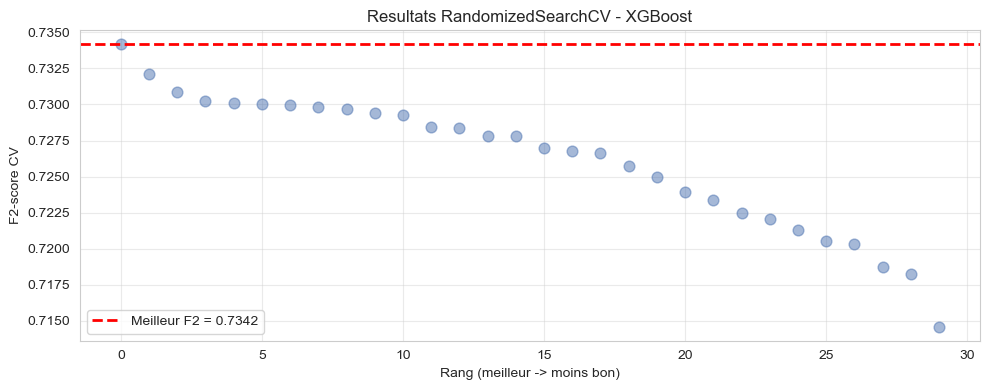

In [39]:
# Selection du meilleur modele
if lgbm_search.best_score_ >= xgb_search.best_score_:
    best_search, best_name = lgbm_search, 'LightGBM'
else:
    best_search, best_name = xgb_search, 'XGBoost'

print(f'Meilleur modele tunne : {best_name} (F2 CV = {best_search.best_score_:.4f})')

# Visualisation de la recherche
cv_res_df = pd.DataFrame(best_search.cv_results_).sort_values('rank_test_score')

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(range(len(cv_res_df)), cv_res_df['mean_test_score'],
           alpha=0.5, color='#4C72B0', s=60)
ax.axhline(best_search.best_score_, color='red', linestyle='--', lw=2,
           label=f'Meilleur F2 = {best_search.best_score_:.4f}')
ax.set_xlabel('Rang (meilleur -> moins bon)')
ax.set_ylabel('F2-score CV')
ax.set_title(f'Resultats RandomizedSearchCV - {best_name}')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

---
## Etape 11 - Entrainement Final

### Objectif

Reentrainer le meilleur modele tunne sur l'integralite du train.

### Pourquoi reentrainer ?

Pendant le RandomizedSearchCV, chaque combinaison de parametres etait evaluee sur des sous-ensembles du train (les folds). Le modele final utilise maintenant 100% des donnees d'entrainement, ce qui lui permet d'apprendre davantage de patterns.

In [ ]:
final_model = best_search.best_estimator_
final_model.fit(X_train, y_train)
print(f'Modele final ({best_name}) reentrainee sur {len(X_train):,} observations.')
print(f'Parametres : {best_search.best_params_}')

---
## Etape 12 - Evaluation Finale

### Objectif

Mesurer les vraies performances sur le test set, jamais vu pendant l'entrainement.

### Les metriques utilisees

#### F2-score (metrique principale)
Comme explique en etape 9 : le recall compte deux fois plus que la precision.

#### Brier Score

C'est la metrique des meteorologues professionnels. Elle mesure la qualite des probabilites predites, pas seulement la decision binaire.

    Brier Score = (1/n) * somme des (probabilite_predite - valeur_reelle)^2

Un service meteo ne dit pas "il pleuvra demain" - il dit "70% de risque de pluie". Le Brier Score mesure si ces probabilites sont bien calibrees. Si le modele annonce 70% pour 100 jours, il devrait effectivement pleuvoir environ 70 fois parmi ces 100 jours.

- Brier Score = 0 : predictions parfaites
- Brier Score = 0.25 : equivalent a un modele aleatoire sur une classe equilibree
- Plus la valeur est basse, mieux c'est

#### ROC-AUC

Mesure la capacite discriminante du modele pour tous les seuils possibles. AUC = 1 est parfait, AUC = 0.5 est aleatoire. C'est une metrique independante du seuil de decision.

#### Optimisation du seuil de decision

Par defaut, un modele predit "Rain" si proba > 0.5. Ce seuil n'est pas toujours optimal pour maximiser le F2-score. On cherche le seuil qui maximise le F2 sur la courbe Precision-Rappel.

In [ ]:
y_pred  = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

# Seuil optimal pour F2
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f2_by_thresh = (1 + 2**2) * precisions[:-1] * recalls[:-1] / (2**2 * precisions[:-1] + recalls[:-1] + 1e-9)
best_idx    = np.argmax(f2_by_thresh)
best_thresh = thresholds[best_idx]
y_pred_opt  = (y_proba >= best_thresh).astype(int)

f2_default = fbeta_score(y_test, y_pred, beta=2)
f2_opt     = fbeta_score(y_test, y_pred_opt, beta=2)
f1_opt     = f1_score(y_test, y_pred_opt)
roc        = roc_auc_score(y_test, y_proba)
brier      = brier_score_loss(y_test, y_proba)
logloss    = log_loss(y_test, y_proba)

report = classification_report(y_test, y_pred_opt, output_dict=True)

print('=' * 58)
print(f'RESULTATS FINAUX - {best_name} | Split chronologique')
print('=' * 58)
print(f'Seuil optimise         : {best_thresh:.3f} (au lieu de 0.5)')
print(f'F2-score (seuil opt.)  : {f2_opt:.4f}   <- metrique principale')
print(f'F2-score (seuil 0.5)   : {f2_default:.4f}')
print(f'F1-score (seuil opt.)  : {f1_opt:.4f}')
print(f'Recall  Rain           : {report["1"]["recall"]:.4f}')
print(f'Precision Rain         : {report["1"]["precision"]:.4f}')
print(f'ROC-AUC                : {roc:.4f}')
print(f'Brier Score Loss       : {brier:.4f}  (plus bas = mieux)')
print(f'Log Loss               : {logloss:.4f}')
print('=' * 58)
print()
print(classification_report(y_test, y_pred_opt, target_names=['No Rain','Rain']))

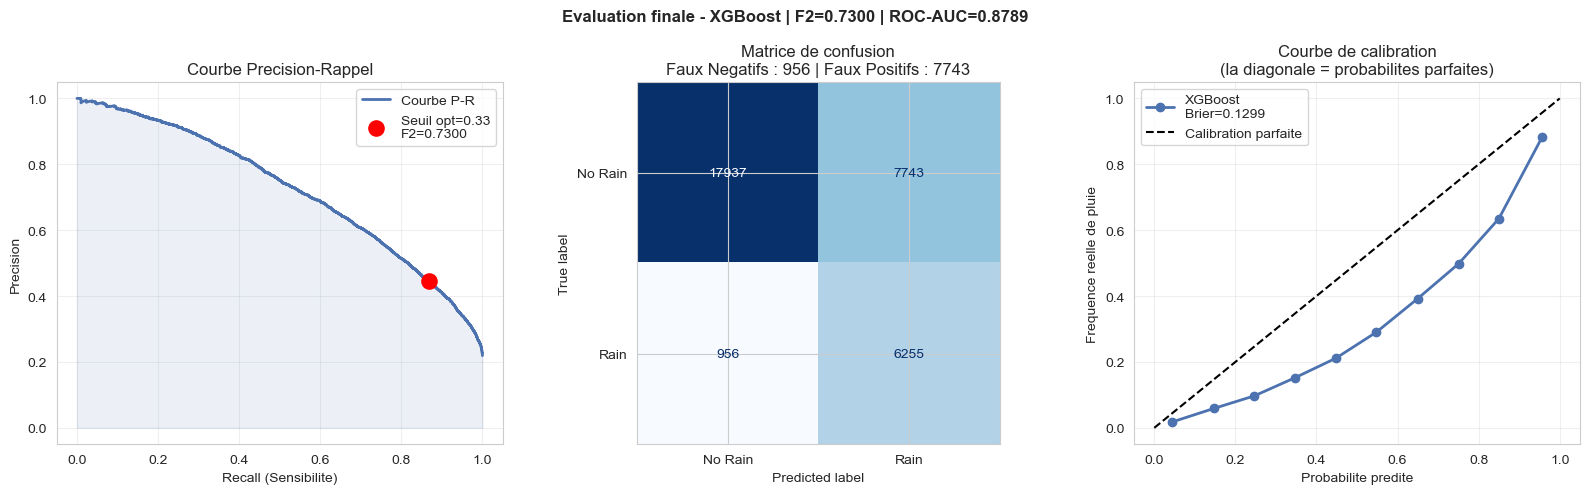

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Courbe Precision-Rappel
axes[0].plot(recalls[:-1], precisions[:-1], color='#4C72B0', lw=2, label='Courbe P-R')
axes[0].scatter(recalls[best_idx], precisions[best_idx], color='red', s=120, zorder=5,
                label=f'Seuil opt={best_thresh:.2f}\nF2={f2_opt:.4f}')
axes[0].fill_between(recalls[:-1], precisions[:-1], alpha=0.1, color='#4C72B0')
axes[0].set_xlabel('Recall (Sensibilite)')
axes[0].set_ylabel('Precision')
axes[0].set_title('Courbe Precision-Rappel')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm, display_labels=['No Rain','Rain']).plot(ax=axes[1], colorbar=False, cmap='Blues')
fn = ((y_test==1) & (y_pred_opt==0)).sum()
fp = ((y_test==0) & (y_pred_opt==1)).sum()
axes[1].set_title(f'Matrice de confusion\nFaux Negatifs : {fn} | Faux Positifs : {fp}')

# Courbe de calibration (Brier)
frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)
axes[2].plot(mean_pred, frac_pos, marker='o', color='#4C72B0', lw=2, label=f'{best_name}\nBrier={brier:.4f}')
axes[2].plot([0,1],[0,1],'k--', lw=1.5, label='Calibration parfaite')
axes[2].set_xlabel('Probabilite predite')
axes[2].set_ylabel('Frequence reelle de pluie')
axes[2].set_title('Courbe de calibration\n(la diagonale = probabilites parfaites)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(f'Evaluation finale - {best_name} | F2={f2_opt:.4f} | ROC-AUC={roc:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '04_evaluation.png'), dpi=100, bbox_inches='tight')
plt.show()

### 12.2 - Analyse des erreurs

In [26]:
results_df = X_test.copy()
results_df['y_true']     = y_test.values
results_df['y_pred']     = y_pred_opt
results_df['y_proba']    = y_proba
results_df['error_type'] = 'Correct'
results_df.loc[(results_df['y_true']==1)&(results_df['y_pred']==0), 'error_type'] = 'Faux Negatif'
results_df.loc[(results_df['y_true']==0)&(results_df['y_pred']==1), 'error_type'] = 'Faux Positif'

fn_df = results_df[results_df['error_type'] == 'Faux Negatif']
fp_df = results_df[results_df['error_type'] == 'Faux Positif']

print(f'Faux Negatifs (pluie manquee) : {len(fn_df):,} ({len(fn_df)/len(y_test)*100:.1f}%)')
print(f'Faux Positifs (fausse alarme) : {len(fp_df):,} ({len(fp_df)/len(y_test)*100:.1f}%)')
print(f'Predictions correctes         : {(results_df["error_type"]=="Correct").sum():,} ({(results_df["error_type"]=="Correct").sum()/len(y_test)*100:.1f}%)')

print('\nProfil des Faux Negatifs (jours de pluie non detectes) :')
cols_show = ['Humidity3pm', 'Pressure9am', 'Rainfall', 'y_proba']
cols_show = [c for c in cols_show if c in fn_df.columns]
print(fn_df[cols_show].describe().round(3))

Faux Negatifs (pluie manquee) : 956 (2.9%)
Faux Positifs (fausse alarme) : 7,743 (23.5%)
Predictions correctes         : 24,192 (73.6%)

Profil des Faux Negatifs (jours de pluie non detectes) :
       Humidity3pm  Pressure9am  Rainfall  y_proba
count      916.000      828.000   920.000  956.000
mean        45.179     1017.220     0.836    0.199
std         15.759        6.183     3.201    0.088
min          6.000      998.700     0.000    0.005
25%         33.000     1012.975     0.000    0.130
50%         46.000     1017.100     0.000    0.208
75%         57.000     1021.500     0.200    0.277
max         98.000     1035.400    42.600    0.333


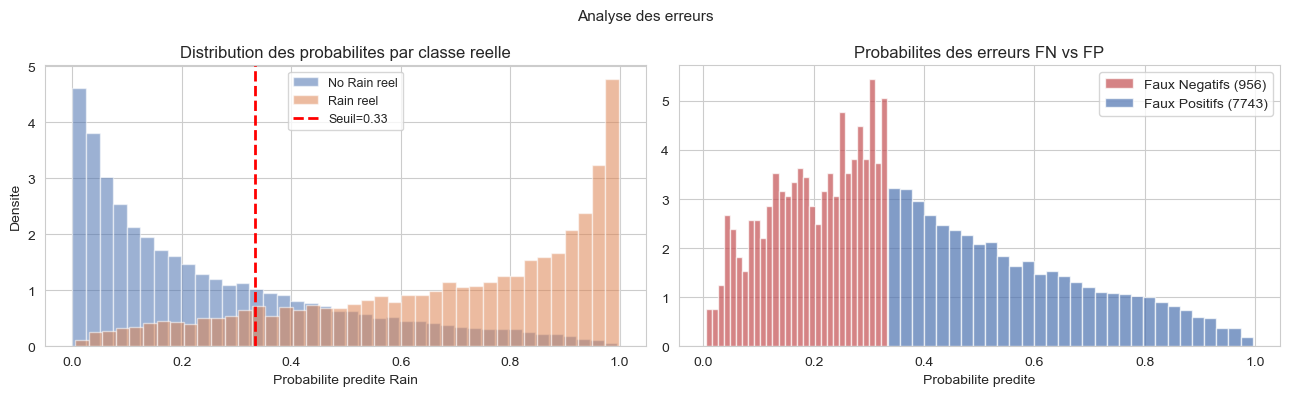

Les Faux Negatifs ont des probabilites proches du seuil.
Ce sont des cas meteorologiquement ambigus, difficiles a ameliorer sans donnees supplementaires.


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color, name in [(0,'#4C72B0','No Rain reel'), (1,'#DD8452','Rain reel')]:
    subset = results_df[results_df['y_true']==label]['y_proba']
    axes[0].hist(subset, bins=40, alpha=0.55, color=color, label=name, density=True)
axes[0].axvline(best_thresh, color='red', lw=2, linestyle='--',
                label=f'Seuil={best_thresh:.2f}')
axes[0].set_xlabel('Probabilite predite Rain')
axes[0].set_ylabel('Densite')
axes[0].set_title('Distribution des probabilites par classe reelle')
axes[0].legend(fontsize=9)

axes[1].hist(fn_df['y_proba'], bins=30, alpha=0.7, color='#C44E52',
             label=f'Faux Negatifs ({len(fn_df)})', density=True)
axes[1].hist(fp_df['y_proba'], bins=30, alpha=0.7, color='#4C72B0',
             label=f'Faux Positifs ({len(fp_df)})', density=True)
axes[1].set_xlabel('Probabilite predite')
axes[1].set_title('Probabilites des erreurs FN vs FP')
axes[1].legend()

plt.suptitle('Analyse des erreurs', fontsize=11)
plt.tight_layout()
plt.show()
print('Les Faux Negatifs ont des probabilites proches du seuil.')
print('Ce sont des cas meteorologiquement ambigus, difficiles a ameliorer sans donnees supplementaires.')

### 12.3 - Importance des features

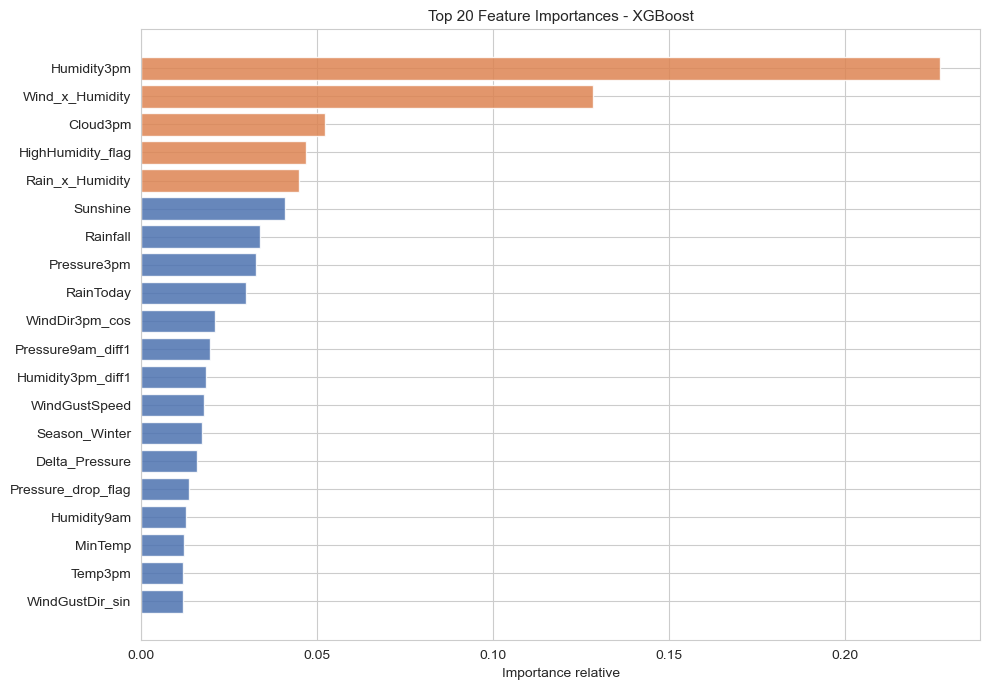

Top 10 features les plus importantes :
  Humidity3pm                         0.2271
  Wind_x_Humidity                     0.1284
  Cloud3pm                            0.0523
  HighHumidity_flag                   0.0468
  Rain_x_Humidity                     0.0448
  Sunshine                            0.0410
  Rainfall                            0.0337
  Pressure3pm                         0.0326
  RainToday                           0.0299
  WindDir3pm_cos                      0.0210


In [28]:
model_step        = final_model.named_steps['model']
selector_step     = final_model.named_steps['selector']
preprocessor_step = final_model.named_steps['preprocessor']

ohe_cols_final = preprocessor_step.named_transformers_['cat']['ohe'].get_feature_names_out(categorical_features)
all_feat_names = np.array(numeric_features + list(ohe_cols_final))
selected_mask  = selector_step.get_support()
selected_names = all_feat_names[selected_mask]

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    feat_imp = pd.DataFrame({'feature': selected_names, 'importance': importances})
    feat_imp = feat_imp.sort_values('importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors_imp = ['#DD8452' if i < 5 else '#4C72B0' for i in range(len(feat_imp))]
    ax.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1],
            color=colors_imp[::-1], alpha=0.85)
    ax.set_title(f'Top 20 Feature Importances - {best_name}', fontsize=11)
    ax.set_xlabel('Importance relative')
    plt.tight_layout()
    plt.show()

    print('Top 10 features les plus importantes :')
    for _, row in feat_imp.head(10).iterrows():
        print(f'  {row["feature"]:<35} {row["importance"]:.4f}')

---
## Etape 13 - Interpretabilite : comprendre les decisions du modele

### Le probleme du modele boite noire

Un modele XGBoost ou LightGBM produit des predictions tres performantes, mais son fonctionnement interne est opaque. On sait ce qu'il predit, pas pourquoi. Pour un meteorologiste ou un agronome qui s'appuie sur ces predictions, cette opacite est un probleme reel.

L'interpretabilite repond a deux besoins distincts. Le premier est la validation physique : les variables que le modele juge importantes doivent correspondre a ce que la physique atmospherique nous dit. Si la pression et l'humidite n'apparaissent pas parmi les variables dominantes, quelque chose ne va pas. Le second est la confiance : un utilisateur final accepte mieux une prediction qu'il peut partiellement expliquer.

### SHAP : les valeurs de Shapley appliquees au Machine Learning

SHAP (SHapley Additive exPlanations) est la methode d'interpretabilite la plus rigoureuse disponible pour les modeles d'ensemble. Elle repose sur les valeurs de Shapley, introduites en theorie des jeux cooperatifs en 1953 et adaptees au ML par Lundberg et Lee en 2017.

L'idee centrale est de distribuer equitablement la contribution de chaque feature a une prediction. Pour chaque observation, SHAP decompose l'ecart entre la prediction et la prediction moyenne en une somme de contributions individuelles, une par feature.

Exemple concret : si le modele predit 78% de probabilite de pluie alors que la moyenne generale est 22%, SHAP attribue cet ecart de +56 points a chacune des features. Par exemple : Humidity3pm contribue a +20 points, Delta_Pressure a +15 points, Rainfall_roll3_mean a +8 points, etc. La somme de toutes les contributions egale exactement l'ecart total.

Un score SHAP positif signifie que la feature augmente la probabilite predite de pluie. Un score negatif signifie qu'elle la diminue.

### Pourquoi SHAP et pas d'autres methodes

LIME (Local Interpretable Model-agnostic Explanations) construit une approximation lineaire locale de la prediction. Elle est moins stable que SHAP sur des donnees correlees : l'humidite et la pression varient ensemble, ce qui perturbe les approximations locales.

La permutation des features (Permutation Feature Importance) donne une importance globale mais pas la direction de l'effet. On sait qu'une feature est importante, pas si elle augmente ou diminue la probabilite de pluie. Cette information directionnelle est indispensable pour valider la coherence physique du modele.

SHAP dispose de deux avantages decisifs pour des donnees meteorologiques. La direction de l'effet est explicite : si Delta_Pressure (baisse de pression dans la journee) a des valeurs SHAP positives quand il est negatif, cela confirme que le modele a bien appris que les baisses de pression precedent la pluie, ce qui est physiquement correct. De plus, SHAP utilise pour les modeles a arbres un algorithme exact appele TreeExplainer, qui calcule les valeurs de Shapley en temps polynomial plutot qu'exponentiel, rendant le calcul faisable en quelques secondes sur plusieurs milliers d'observations.

In [29]:
import shap

# Reconstruction des noms de features apres le preprocesseur et SelectKBest.
# Le Pipeline a transforme X_train en deux etapes successives :
# 1) le ColumnTransformer (imputation + scaling + OneHotEncoding)
# 2) SelectKBest qui garde les k features les plus informatives.
# On doit retrouver les noms correspondant aux colonnes effectivement conservees.
ohe_step = final_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe']
cat_names_out = list(ohe_step.get_feature_names_out(categorical_features))
all_preprocessed_names = numeric_features + cat_names_out

selector_step = final_model.named_steps['selector']
selected_names_shap = [all_preprocessed_names[i] for i in selector_step.get_support(indices=True)]

print(f'Features selectionnees par le pipeline : {len(selected_names_shap)}')

# Le calcul SHAP exact (TreeExplainer) est rapide mais on limite a 2000 observations
# pour que les graphiques restent lisibles. Les importances sont stables
# a partir de quelques centaines d'observations.
N_SHAP = min(2000, len(X_test))
rng_shap = np.random.default_rng(RANDOM_STATE)
idx_shap = rng_shap.choice(len(X_test), size=N_SHAP, replace=False)
X_shap_raw = X_test.iloc[idx_shap].reset_index(drop=True)
y_shap     = y_test.iloc[idx_shap].reset_index(drop=True)

X_shap_prep = final_model.named_steps['preprocessor'].transform(X_shap_raw)
X_shap_sel  = selector_step.transform(X_shap_prep)
X_shap_df   = pd.DataFrame(X_shap_sel, columns=selected_names_shap)

print(f'Calcul des valeurs SHAP sur {N_SHAP} observations (TreeExplainer)...')
explainer_shap = shap.TreeExplainer(final_model.named_steps['model'])
sv = explainer_shap.shap_values(X_shap_sel)

# LightGBM en classification binaire renvoie une liste [classe_0, classe_1].
# On extrait les valeurs pour la classe positive (pluie = 1).
# XGBoost renvoie directement le tableau pour la classe positive.
if isinstance(sv, list):
    sv = sv[1]

mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=selected_names_shap)
mean_abs_shap = mean_abs_shap.sort_values(ascending=False)
top20_shap = mean_abs_shap.head(20).index.tolist()
top10_shap = mean_abs_shap.head(10).index.tolist()
top4_shap  = mean_abs_shap.head(4).index.tolist()

print('Calcul termine.')
print()
print('Top 10 features par importance SHAP globale (mean |SHAP|) :')
for rang, (feat, val) in enumerate(mean_abs_shap.head(10).items(), 1):
    print(f'  {rang:>2}. {feat:<35} {val:.4f}')

Features selectionnees par le pipeline : 40
Calcul des valeurs SHAP sur 2000 observations (TreeExplainer)...
Calcul termine.

Top 10 features par importance SHAP globale (mean |SHAP|) :
   1. Humidity3pm                         0.5993
   2. Wind_x_Humidity                     0.4713
   3. Pressure3pm                         0.2498
   4. Sunshine                            0.2267
   5. Rainfall                            0.1842
   6. Delta_Pressure                      0.1587
   7. Cloud3pm                            0.1383
   8. Humidity9am                         0.1303
   9. WindGustSpeed                       0.1108
  10. Pressure9am_diff1                   0.1092


### 13.1 - Importance globale et beeswarm

Le bar chart montre l'importance moyenne de chaque feature, calculee comme la moyenne des valeurs SHAP absolues sur toutes les observations. C'est une vue agregee : on voit quelles features comptent le plus en moyenne, sans distinguer si leur effet est positif ou negatif.

Le beeswarm complete cette vue. Chaque point represente une observation du test set. La position horizontale est la valeur SHAP (impact sur la prediction). La couleur indique la valeur originale de la feature avant transformation : rouge pour les valeurs elevees, bleu pour les valeurs basses.

Lecture pratique du beeswarm : si les points rouges de Humidity3pm sont a droite de zero, cela signifie qu'une humidite elevee augmente la probabilite predite de pluie, ce qui est physiquement attendu. Si les points bleus de Pressure9am sont a droite, cela signifie qu'une basse pression augmente la probabilite de pluie, ce qui correspond a l'effet connu des depressions atmospheriques.

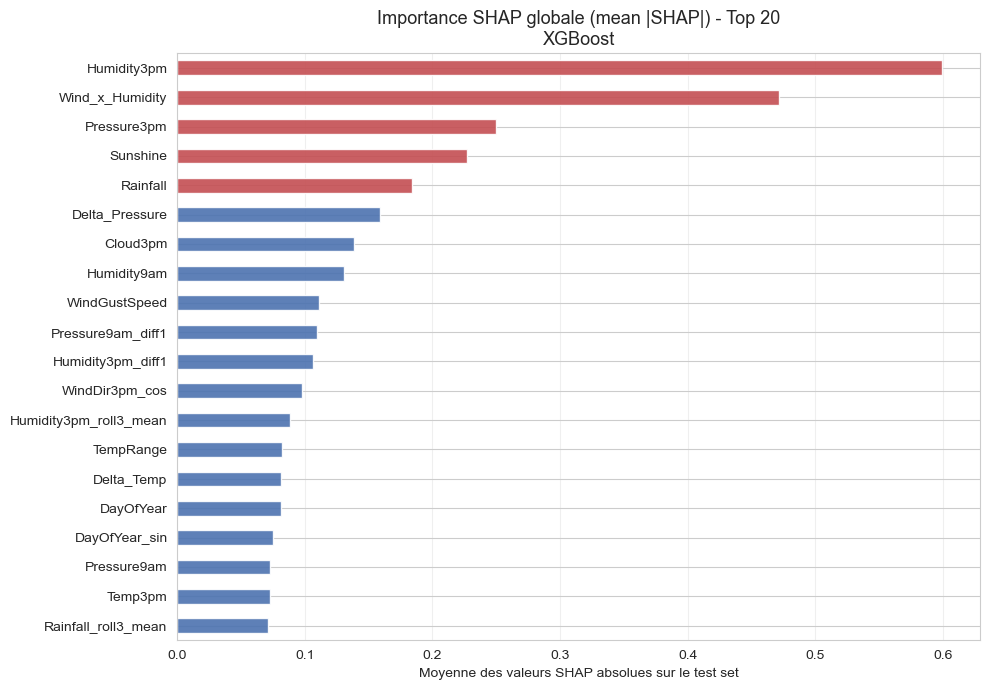

In [30]:
# Bar chart : importance globale (mean |SHAP|).
# Les 5 premieres features sont colorees en rouge pour les mettre en evidence.
fig, ax = plt.subplots(figsize=(10, 7))
colors_shap = ['#C44E52' if i < 5 else '#4C72B0' for i in range(20)]
mean_abs_shap.head(20).sort_values().plot(
    kind='barh', ax=ax,
    color=colors_shap[::-1],
    edgecolor='white', alpha=0.9
)
ax.set_title(f'Importance SHAP globale (mean |SHAP|) - Top 20\n{best_name}', fontsize=13)
ax.set_xlabel('Moyenne des valeurs SHAP absolues sur le test set')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '05a_shap_importance.png'), dpi=100, bbox_inches='tight')
plt.show()

In [1]:
# Beeswarm SHAP via l'API Explanation (SHAP >= 0.40).
# Chaque point est une observation du test set.
# Axe horizontal : valeur SHAP (impact sur la prediction).
# Couleur : valeur originale de la feature (rouge = haute, bleu = basse).
# values/data/feature_names doivent porter sur LES MEMES colonnes (top 20)
# sinon SHAP leve une erreur de shape (k_selectkbest != 20).
top20_idx = [selected_names_shap.index(f) for f in top20_shap]
shap_exp = shap.Explanation(
    values=sv[:, top20_idx],
    data=X_shap_df[top20_shap].values,
    feature_names=top20_shap
)
plt.figure()
# Colormap RdBu_r pour un rendu identique au pipeline (rouge = haute, bleu = basse).
shap.plots.beeswarm(shap_exp, max_display=20, color=plt.get_cmap('RdBu_r'), show=False)
plt.title(f'SHAP Beeswarm - {best_name}', fontsize=12, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '05b_shap_beeswarm.png'), dpi=100, bbox_inches='tight')
plt.show()

NameError: name 'top20_shap' is not defined

### 13.2 - Graphiques de dependance SHAP

Un graphique de dependance SHAP montre comment la valeur SHAP d'une feature evolue en fonction de sa valeur numerique brute. C'est l'equivalent d'une Partial Dependence Plot, mais observation par observation plutot que sur une moyenne agregee.

L'axe horizontal est la valeur brute de la feature (par exemple l'humidite en pourcentage). L'axe vertical est la valeur SHAP correspondante (l'impact sur la prediction). La couleur indique la valeur d'une seconde feature selectionnee automatiquement par SHAP comme la plus correllee avec la premiere : cela revele les interactions entre variables.

En meteorologie, ces graphiques permettent de verifier que les seuils physiques connus sont retrouves par le modele. On s'attend a ce que la valeur SHAP de Humidity3pm devienne fortement positive au-dela de 80-85%, ce qui correspond au seuil de saturation atmospherique. On s'attend aussi a ce que Delta_Pressure ait des valeurs SHAP positives quand il est negatif, c'est-a-dire que le modele a appris que les baisses de pression dans la journee annoncent la pluie. Si ces patterns ne sont pas presents, le modele a peut-etre appris des artefacts plutot que la physique.

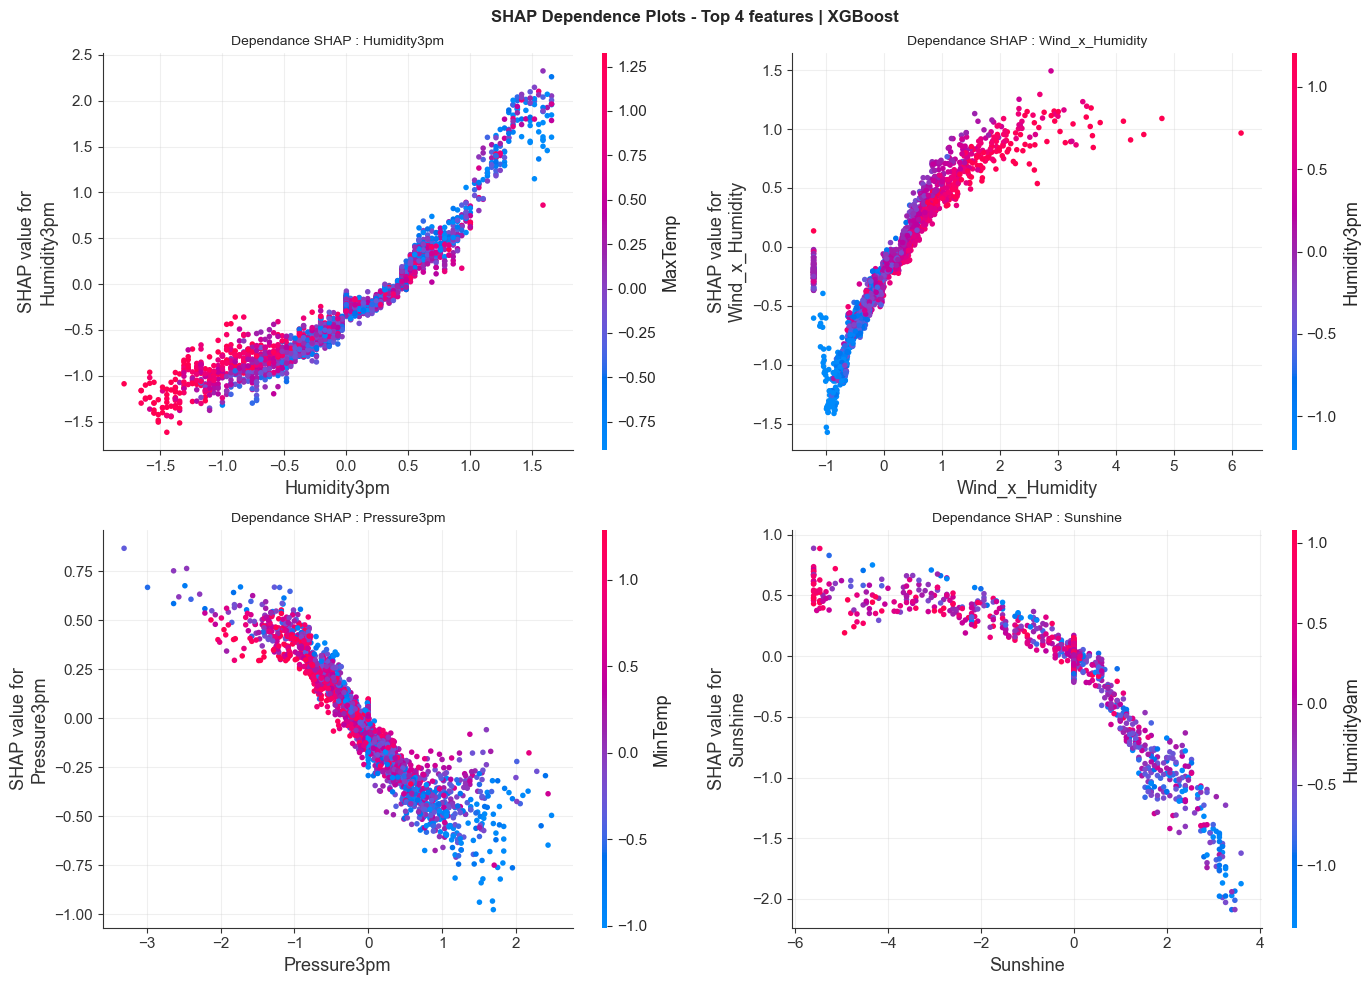

In [35]:
# Dependence plots pour les 4 features les plus importantes selon SHAP.
# La couleur de chaque point indique la valeur d'une feature d'interaction
# selectionnee automatiquement comme la plus correllee.
# Un nuage de points verticalement disperse indique une forte interaction entre les deux features.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.flatten(), top4_shap):
    try:
        shap.dependence_plot(feat, sv, X_shap_df, ax=ax, show=False, interaction_index='auto')
    except Exception:
        shap.dependence_plot(feat, sv, X_shap_df, ax=ax, show=False, interaction_index=None)
    ax.set_title(f'Dependance SHAP : {feat}', fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle(f'SHAP Dependence Plots - Top 4 features | {best_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '06_shap_dependence.png'), dpi=100, bbox_inches='tight')
plt.show()

### 13.3 - Analyse saisonniere de l'interpretabilite

L'Australie presente quatre saisons aux regimes de pluie tres differents. L'hiver austral (juin-aout) est la saison pluvieuse dans le sud et le sud-ouest, sous l'influence des fronts de l'ocean Indien. L'ete (decembre-fevrier) correspond a la saison humide tropicale dans le nord, liee aux moussons.

L'analyse saisonniere des valeurs SHAP permet de verifier que le modele a bien appris ces patterns climatiques. Si la contribution de l'humidite est plus importante en ete qu'en hiver, cela reflete le fait que l'humidite tropicale estivale est un meilleur predicteur dans le nord. Si la contribution de la pression est plus importante en hiver, cela reflete l'influence des depressions frontales hivernales dans le sud.

La heatmap montre l'importance moyenne de chaque feature par saison. Le boxplot ci-dessous decompose la distribution des valeurs SHAP pour la feature la plus importante : on voit non seulement si la feature est importante selon la saison, mais aussi si son effet est systematiquement positif ou negatif. Un boxplot entierement au-dessus de zero signifie que cette feature augmente la probabilite de pluie dans toutes les observations de cette saison.

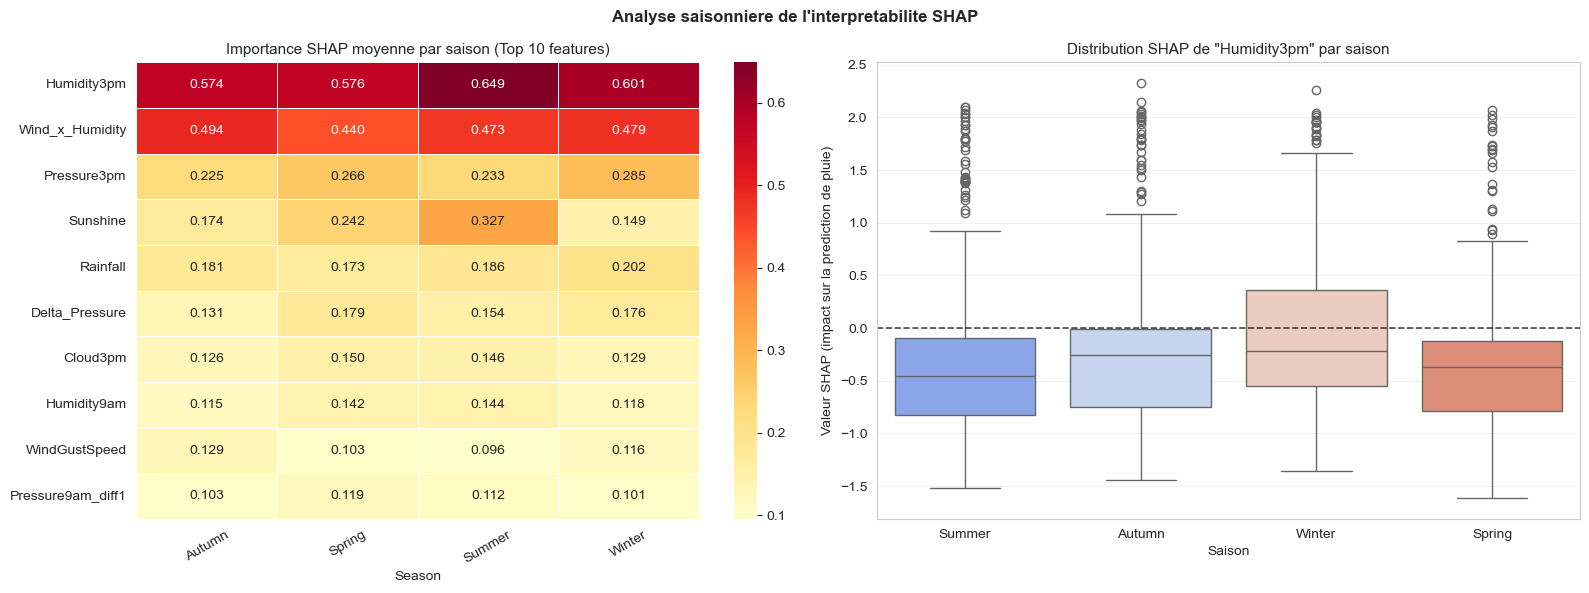

In [36]:
sv_df_shap = pd.DataFrame(sv, columns=selected_names_shap)
sv_df_shap['Season'] = X_shap_raw['Season'].values

# Importance moyenne par saison.
# On prend la valeur absolue pour mesurer l'amplitude de l'impact,
# independamment de sa direction (positive ou negative).
season_mean_shap = sv_df_shap.groupby('Season')[top10_shap].apply(lambda d: d.abs().mean())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(season_mean_shap.T, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Importance SHAP moyenne par saison (Top 10 features)", fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

# Distribution des valeurs SHAP brutes (signees) pour la feature principale.
# Un boxplot au-dessus de zero indique que la feature augmente la probabilite de pluie.
# Un boxplot en-dessous de zero indique qu'elle la diminue.
top_feature_saison = top4_shap[0]
bp_data = pd.DataFrame({
    'SHAP'  : sv_df_shap[top_feature_saison].values,
    'Season': X_shap_raw['Season'].values
})
season_order = [s for s in ['Summer', 'Autumn', 'Winter', 'Spring']
                if s in bp_data['Season'].unique()]
sns.boxplot(data=bp_data, x='Season', y='SHAP', order=season_order,
            palette='coolwarm', ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', lw=1.2, alpha=0.7)
axes[1].set_title(f'Distribution SHAP de "{top_feature_saison}" par saison', fontsize=11)
axes[1].set_xlabel('Saison')
axes[1].set_ylabel('Valeur SHAP (impact sur la prediction de pluie)')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Analyse saisonniere de l'interpretabilite SHAP", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '07_shap_seasonal.png'), dpi=100, bbox_inches='tight')
plt.show()

### 13.4 - Cartographie : analyse spatiale par station

L'Australie est un continent aux climats tres heterogenes. Darwin (tropical humide avec une mousson marquee), Perth (mediterraneen avec des pluies hivernales), Hobart (tempere oceanien) et Alice Springs (aride avec moins de 300 mm par an) n'ont pas les memes patterns de pluie. Un bon modele doit gerer cette diversite sans se sur-specialiser sur certaines regions.

La carte suivante represente les 49 stations meteorologiques du dataset. Trois metriques sont affichees simultanement.

Le taux de pluie reel indique la frequence historique de la pluie dans chaque ville. Les stations du nord (Darwin, Cairns) ont des taux eleves, les stations du centre (Alice Springs, Woomera) ont des taux tres bas. Cette distribution geographique est attendue et sert de reference.

Le recall par station mesure la proportion de jours de pluie que le modele a correctement identifies dans chaque ville. Un recall faible dans une region specifique signale que le modele a du mal a detecter la pluie dans ce contexte climatique, meme si ses performances globales sont bonnes.

L'accuracy globale par station complete l'analyse en montrant ou le modele se trompe le plus souvent, toutes erreurs confondues. La taille de chaque bulle est proportionnelle au nombre d'observations disponibles pour cette station dans le test set.

Location dans top 20 SHAP : NON


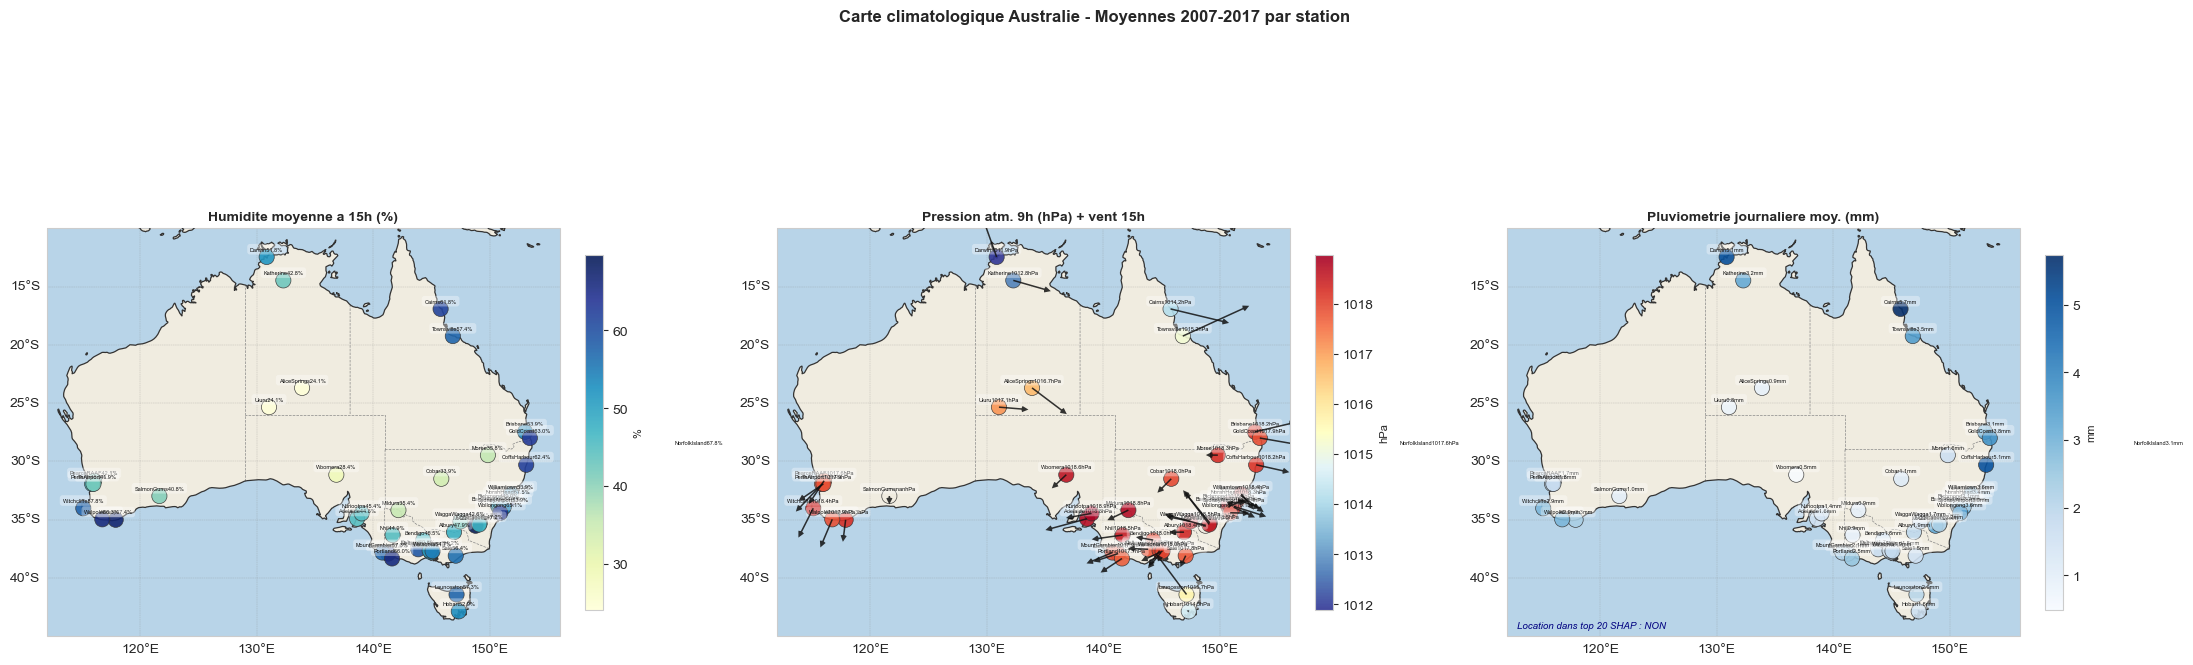

In [37]:
import cartopy.crs     as ccrs
import cartopy.feature  as cfeature

# Coordonnees geographiques des 49 stations meteorologiques.
LOCATION_COORDS = {
    'Adelaide':         (-34.93, 138.60), 'Albany':           (-35.02, 117.88),
    'Albury':           (-36.08, 146.92), 'AliceSprings':     (-23.70, 133.88),
    'BadgerysCreek':    (-33.88, 150.73), 'Ballarat':         (-37.55, 143.85),
    'Bendigo':          (-36.76, 144.28), 'Brisbane':         (-27.47, 153.02),
    'Cairns':           (-16.92, 145.77), 'Canberra':         (-35.28, 149.13),
    'Cobar':            (-31.50, 145.83), 'CoffsHarbour':     (-30.30, 153.12),
    'Dartmoor':         (-37.92, 141.27), 'Darwin':           (-12.46, 130.84),
    'GoldCoast':        (-28.00, 153.43), 'Hobart':           (-42.88, 147.33),
    'Jabiru':           (-12.66, 132.89), 'Katherine':        (-14.47, 132.27),
    'Launceston':       (-41.43, 147.14), 'Melbourne':        (-37.81, 144.96),
    'MelbourneAirport': (-37.67, 144.83), 'Mildura':          (-34.19, 142.15),
    'Moree':            (-29.47, 149.83), 'MountGambier':     (-37.83, 140.78),
    'MountGinini':      (-35.53, 148.77), 'Newcastle':        (-32.92, 151.78),
    'Nhil':             (-36.33, 141.65), 'NorahHead':        (-33.28, 151.57),
    'NorfolkIsland':    (-29.04, 167.96), 'Nuriootpa':        (-34.47, 138.99),
    'PearceRAAF':       (-31.67, 116.03), 'Penrith':          (-33.75, 150.70),
    'Perth':            (-31.95, 115.86), 'PerthAirport':     (-31.94, 115.97),
    'Portland':         (-38.34, 141.60), 'Richmond':         (-33.60, 150.75),
    'Sale':             (-38.10, 147.07), 'SalmonGums':       (-32.98, 121.63),
    'Sydney':           (-33.87, 151.21), 'SydneyAirport':    (-33.94, 151.18),
    'Townsville':       (-19.25, 146.82), 'Tuggeranong':      (-35.42, 149.09),
    'Uluru':            (-25.35, 131.04), 'WaggaWagga':       (-35.16, 147.47),
    'Walpole':          (-34.98, 116.73), 'Watsonia':         (-37.71, 145.08),
    'Williamtown':      (-32.80, 151.84), 'Witchcliffe':      (-34.03, 115.10),
    'Wollongong':       (-34.42, 150.89), 'Woomera':          (-31.15, 136.82),
}

# Verification SHAP : Location est-elle dans les predicteurs importants ?
loc_in_top20 = [f for f in top20_shap if f.startswith('Location_')]
loc_msg = (f"Location dans top 20 SHAP : OUI ({len(loc_in_top20)} var)"
           if loc_in_top20 else "Location dans top 20 SHAP : NON")
print(loc_msg)

# Statistiques climatologiques sur toute la serie 2007-2017.
wind_dir_map = {
    'N':0, 'NNE':22.5, 'NE':45, 'ENE':67.5, 'E':90, 'ESE':112.5,
    'SE':135, 'SSE':157.5, 'S':180, 'SSW':202.5, 'SW':225, 'WSW':247.5,
    'W':270, 'WNW':292.5, 'NW':315, 'NNW':337.5
}
df_raw_map = pd.read_csv(DATA_PATH)
df_raw_map['_wind_rad'] = df_raw_map['WindDir3pm'].map(wind_dir_map).apply(
    lambda d: np.radians(d) if pd.notna(d) else np.nan)
df_raw_map['_wind_u'] = np.sin(df_raw_map['_wind_rad'])
df_raw_map['_wind_v'] = np.cos(df_raw_map['_wind_rad'])

climate = df_raw_map.groupby('Location').agg(
    humidity = ('Humidity3pm', 'mean'),
    pressure = ('Pressure9am', 'mean'),
    rainfall = ('Rainfall',    'mean'),
    wind_u   = ('_wind_u',     'mean'),
    wind_v   = ('_wind_v',     'mean'),
).reset_index()
climate['lat'] = climate['Location'].map(lambda l: LOCATION_COORDS.get(l, (None, None))[0])
climate['lon'] = climate['Location'].map(lambda l: LOCATION_COORDS.get(l, (None, None))[1])
climate = climate.dropna(subset=['lat', 'lon', 'humidity'])

proj   = ccrs.PlateCarree()
extent = [112, 156, -45, -10]

states_feat = cfeature.NaturalEarthFeature(
    'cultural', 'admin_1_states_provinces_lines', '50m',
    edgecolor='#888', facecolor='none')

panels = [
    ('humidity', 'YlGnBu',   'Humidite moyenne a 15h (%)',         '%',   False),
    ('pressure', 'RdYlBu_r', 'Pression atm. 9h (hPa) + vent 15h', 'hPa', True),
    ('rainfall', 'Blues',    'Pluviometrie journaliere moy. (mm)',  'mm',  False),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 8), subplot_kw={'projection': proj})

for ax, (col, cmap, title, unit, add_quiver) in zip(axes, panels):
    ax.set_extent(extent, crs=proj)
    ax.add_feature(cfeature.OCEAN,     facecolor='#b8d4e8', zorder=0)
    ax.add_feature(cfeature.LAND,      facecolor='#f0ece0', zorder=1)
    ax.add_feature(states_feat,        linewidth=0.5, linestyle='--', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.9, edgecolor='#333', zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.6, edgecolor='#555',
                   linestyle=':', zorder=3)

    vals = climate[col]
    sc = ax.scatter(climate['lon'], climate['lat'],
                    c=vals, cmap=cmap, s=120,
                    vmin=vals.min(), vmax=vals.max(),
                    edgecolors='#333', linewidth=0.5, alpha=0.9,
                    transform=proj, zorder=5)
    cb = plt.colorbar(sc, ax=ax, shrink=0.48, pad=0.04)
    cb.set_label(unit, fontsize=8)

    for _, row in climate.iterrows():
        ax.text(row['lon'], row['lat'] + 0.45,
                f"{row['Location']}{row[col]:.1f}{unit}",
                fontsize=4, ha='center', va='bottom',
                transform=proj, color='#111', zorder=6,
                bbox=dict(facecolor='white', alpha=0.35, pad=0.5,
                          edgecolor='none', boxstyle='round'))

    if add_quiver:
        ax.quiver(climate['lon'], climate['lat'],
                  climate['wind_u'], climate['wind_v'],
                  color='#111', alpha=0.85,
                  transform=proj, zorder=7,
                  width=0.003, headwidth=4, headlength=4)

    ax.set_title(title, fontsize=10, fontweight='bold')
    gl = ax.gridlines(draw_labels=True, linewidth=0.3,
                      alpha=0.5, color='gray', linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False

axes[2].text(0.02, 0.02, loc_msg, transform=axes[2].transAxes,
             fontsize=7, color='navy', style='italic')

plt.suptitle('Carte climatologique Australie - Moyennes 2007-2017 par station',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '08_australia_map.png'), dpi=120, bbox_inches='tight')
plt.show()

### Synthese de l'interpretabilite

L'analyse SHAP permet de valider le modele sur trois dimensions complementaires.

La coherence meteorologique se lit dans les graphiques de dependance. Les features qui doivent theoriquement predire la pluie doivent apparaitre en haut du classement SHAP et avec une direction positive. Si Delta_Pressure a des valeurs SHAP positives quand il est negatif (baisse de pression), le modele a bien appris ce signal classique avant-coureur de front pluvieux.

La coherence saisonniere se lit dans la heatmap. Un bon modele ne devrait pas utiliser les memes features avec la meme intensite en ete tropical (Darwin, Cairns) et en hiver tempere (Hobart, Adelaide). Si les features associees a la mousson estivale dominent en ete et celles associees aux fronts dominent en hiver, le modele a correctement distingue les deux regimes.

La coherence spatiale se lit dans la carte. Un recall particulierement faible dans une region indique une limite du modele dans ce contexte climatique. Les regions arides du centre (Alice Springs, Woomera) ont peu d'observations et une pluie tres irreguliere, ce qui rend la prediction inheremment difficile. Ce constat oriente les pistes d'amelioration : un modele specialise par zone climatique ou un enrichissement des features pour les regions sous-representees permettrait d'ameliorer significativement ces cas.

---
## Synthese finale

### Decisions cles et justifications

| Etape | Decision | Justification |
|-------|----------|---------------|
| EDA | Analyser avant de modeliser | Comprendre les donnees evite les erreurs coteuses |
| Cleaning | Aberrations physiques uniquement | Trop nettoyer = perte de signal utile |
| Feature Engineering | Sin/cos cyclique + derivees temporelles | Encode la physique meteorologique |
| Split | Chronologique (pas aleatoire) | Donnees temporelles : pas de regard vers le futur |
| Preprocessing | RobustScaler + Pipeline | Resistant aux outliers, pas de data leakage |
| Ponderation | sample_weight heuristique | Reduit l'impact du bruit de label |
| Feature Selection | Mutual Information | Capture les relations non-lineaires |
| Resampling | Aucun (pas de SMOTE) | Donnees temporelles, interpolations non physiques |
| Metrique | F2-score (pas F1) | Un Faux Negatif coute plus cher qu'un Faux Positif |
| Calibration | Brier Score + courbe | Les probabilites comptent autant que la decision binaire |
| Interpretabilite | SHAP (TreeExplainer) | Direction de l'effet meteorologique verifiable par la physique + carte spatiale |

In [38]:
print('=' * 62)
print('SYNTHESE FINALE - WEATHER AUSTRALIA')
print('=' * 62)
print(f'Modele selectionne     : {best_name}')
print(f'Split                  : Chronologique')
print(f'Seuil optimise         : {best_thresh:.3f}')
print()
print('METRIQUES SUR TEST SET (jamais vu pendant l\'entrainement) :')
print(f'  F2-score             : {f2_opt:.4f}   <- metrique principale')
print(f'  F1-score             : {f1_opt:.4f}')
print(f'  Recall Rain          : {report["1"]["recall"]:.4f}')
print(f'  Precision Rain       : {report["1"]["precision"]:.4f}')
print(f'  ROC-AUC              : {roc:.4f}')
print(f'  Brier Score Loss     : {brier:.4f}')
print(f'  Faux Negatifs        : {fn:,} ({fn/len(y_test)*100:.1f}%)')
print(f'  Faux Positifs        : {fp:,} ({fp/len(y_test)*100:.1f}%)')
print('=' * 62)
print()
print('Pistes d\'amelioration :')
print('- Ajouter des donnees satellite ou radar (Sunshine tres incompleta)')
print('- Essayer CatBoost (gere nativement les categories sans OHE)')
print('- Entrainer un modele par zone climatique')
print('- Calibration des probabilites (CalibratedClassifierCV)')

SYNTHESE FINALE - WEATHER AUSTRALIA
Modele selectionne     : XGBoost
Split                  : Chronologique
Seuil optimise         : 0.334

METRIQUES SUR TEST SET (jamais vu pendant l'entrainement) :
  F2-score             : 0.7300   <- metrique principale
  F1-score             : 0.5898
  Recall Rain          : 0.8674
  Precision Rain       : 0.4468
  ROC-AUC              : 0.8789
  Brier Score Loss     : 0.1299
  Faux Negatifs        : 956 (2.9%)
  Faux Positifs        : 7,743 (23.5%)

Pistes d'amelioration :
- Ajouter des donnees satellite ou radar (Sunshine tres incompleta)
- Essayer CatBoost (gere nativement les categories sans OHE)
- Entrainer un modele par zone climatique
- Calibration des probabilites (CalibratedClassifierCV)
